In [1]:
%load_ext autoreload
%autoreload 2

# import packages
import xarray as xr
import geopandas as gpd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

from datetime import datetime as dt
from glob import glob
from tqdm import tqdm

# import partial packages
from sklearn.cluster import KMeans, OPTICS
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture

from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.utils import resample
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split, ParameterGrid
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
import seaborn as sns
import itertools

from hdbscan import HDBSCAN

from hdbscan.validity import validity_index


directory = '/scratch/6256481/'

# import sys
# sys.path.insert(0, directory + f'python/py_code/')

# Tuning results

In [3]:
glob(directory + 'results/*')
F = glob(directory + "results/HDBSCAN_*morphology_*.csv")
F

['/scratch/6256481/results/HDBSCAN_chebyshev_morphology_reach_True.csv',
 '/scratch/6256481/results/HDBSCAN_canberra_morphology_reach_True.csv',
 '/scratch/6256481/results/HDBSCAN_euclidean_morphology_reach_True.csv',
 '/scratch/6256481/results/HDBSCAN_manhattan_morphology_reach_True.csv',
 '/scratch/6256481/results/HDBSCAN_chebyshev_morphology_reach_False.csv',
 '/scratch/6256481/results/HDBSCAN_canberra_morphology_reach_False.csv',
 '/scratch/6256481/results/HDBSCAN_euclidean_morphology_reach_False.csv',
 '/scratch/6256481/results/HDBSCAN_manhattan_morphology_reach_False.csv',
 '/scratch/6256481/results/HDBSCAN_chebyshev_morphology_bend_True.csv']

In [4]:
KmeanScoreFiles = glob(directory + 'results/KmeanScores_morphology_*.csv')
for i,f in enumerate(KmeanScoreFiles):
    dfT = pd.read_csv(f, index_col=0)
    strName = f[48:-4]
    strNames = strName.split('_')
    if strNames[1] == 'True':
        pca = '_pca'
    else:
        pca = ''
    dfT = dfT.rename(columns = {'Silhouette':f'Silhouette_{strNames[0]}{pca}',
                      'DaviesB'   :f'DaviesB_{strNames[0]}{pca}'}   )

    if i == 0:
        dfKS = dfT
    else:
        dfKS = dfKS.merge(dfT, how = 'left', on = 'clusters')
dfKS.head(2)

,clusters,Silhouette_reach,DaviesB_reach,Silhouette_reach_pca,DaviesB_reach_pca,Silhouette_bend_pca,DaviesB_bend_pca
0,3,1.000000,1.244176e-07,0.579492,0.877263,0.609400,0.905298
1,4,0.834823,2.972447e-01,0.480555,0.774244,0.595911,0.786960


In [250]:
# def create_runs(met, alg,minP, samp, g1,g2):
        
# metric     = ['chebyshev']
# algo       = ['best']
# minP       = [0]
# sampleSize = [1000]
# grid1 = [100, 120, 140, 160,180,200,220,240]
# grid2 = [60,70,80]



runs1 = list(itertools.product(*[['chebyshev'], ['best'], [0], [40000], 
                                [100, 120, 140, 160,180,200,220,240],
                                [80, 100, 120, 140, 160,180,200,220]]))
runs2 = list(itertools.product(*[['manhattan'], ['best'], [0], [40000], 
                                [60,70,80],
                                [50,60,70,80]]))
runs = runs1 + runs2
[r for r in runs if r[-1] <= r[-2]]



[('chebyshev', 'best', 0, 40000, 100, 80),
 ('chebyshev', 'best', 0, 40000, 100, 100),
 ('chebyshev', 'best', 0, 40000, 120, 80),
 ('chebyshev', 'best', 0, 40000, 120, 100),
 ('chebyshev', 'best', 0, 40000, 120, 120),
 ('chebyshev', 'best', 0, 40000, 140, 80),
 ('chebyshev', 'best', 0, 40000, 140, 100),
 ('chebyshev', 'best', 0, 40000, 140, 120),
 ('chebyshev', 'best', 0, 40000, 140, 140),
 ('chebyshev', 'best', 0, 40000, 160, 80),
 ('chebyshev', 'best', 0, 40000, 160, 100),
 ('chebyshev', 'best', 0, 40000, 160, 120),
 ('chebyshev', 'best', 0, 40000, 160, 140),
 ('chebyshev', 'best', 0, 40000, 160, 160),
 ('chebyshev', 'best', 0, 40000, 180, 80),
 ('chebyshev', 'best', 0, 40000, 180, 100),
 ('chebyshev', 'best', 0, 40000, 180, 120),
 ('chebyshev', 'best', 0, 40000, 180, 140),
 ('chebyshev', 'best', 0, 40000, 180, 160),
 ('chebyshev', 'best', 0, 40000, 180, 180),
 ('chebyshev', 'best', 0, 40000, 200, 80),
 ('chebyshev', 'best', 0, 40000, 200, 100),
 ('chebyshev', 'best', 0, 40000, 200, 

In [240]:
glob(directory + "results/GMMSCORES_morphology_*.csv")

['/scratch/6256481/results/GMMSCORES_morphology_reach_False.csv',
 '/scratch/6256481/results/GMMSCORES_morphology_bend_True.csv',
 '/scratch/6256481/results/GMMSCORES_morphology_reach_True.csv',
 '/scratch/6256481/results/GMMSCORES_morphology_reach_<multiprocessing.pool.Pool state=TERMINATE pool_size=10>.csv',
 '/scratch/6256481/results/GMMSCORES_morphology_bend_<multiprocessing.pool.Pool state=TERMINATE pool_size=10>.csv',
 '/scratch/6256481/results/GMMSCORES_morphology_bend_False.csv']

In [238]:
GMMScoreFiles   = glob(directory + "results/GMMSCORES_morphology_*.csv")a
# GMMScoreFiles   = glob(directory + 'results/GMMSCORES_conf*merg*')
for i,f in enumerate(GMMScoreFiles):
    dfT = pd.read_csv(f, index_col=0)
    strName = f[46:-4]
    strNames = strName.split('_')

    if strNames[1] == 'True':
        pca = '_pca'
    else:
        pca = ''
    dfT = dfT.rename(columns = {'Silhouette':f'Silhouette_{strNames[0]}{pca}',
                                'DaviesB'   :f'DaviesB_{strNames[0]}{pca}',
                                'BIC'   :f'BIC_{strNames[0]}{pca}',
                                'AIC'   :f'AIC_{strNames[0]}{pca}'}   )
    # print(dfT.head(2))
    if i == 0:
        # 
        dfGS = dfT

    else:

        dfT = dfT.drop(['max_iter', 'init'], axis = 1)
        dfGS = dfGS.merge(dfT, how = 'left', on = ['cov_type','clusters'])
dfGS.head(2)

,max_iter,cov_type,init,clusters,BIC_reach,AIC_reach,Silhouette_reach,DaviesB_reach,BIC_bend_pca,AIC_bend_pca,Silhouette_bend_pca,DaviesB_bend_pca,BIC_reach_pca,AIC_reach_pca,Silhouette_reach_pca,DaviesB_reach_pca
0,100,diag,5,3,NaN,NaN,NaN,NaN,-8.902557e+06,-8.902874e+06,0.292277,1.997263,-1.600842e+06,-1.601098e+06,0.208050,1.804571
1,100,diag,5,4,NaN,NaN,NaN,NaN,-1.005808e+07,-1.005851e+07,0.292505,1.979581,-1.711013e+06,-1.711358e+06,0.161745,1.702355


In [6]:
HDBSCANFiles = glob(directory + "results/HDBSCAN_*morphology_*.csv")
for i,f in enumerate(HDBSCANFiles):
    dfT = pd.read_csv(f, index_col=0)
    strNames = f[33:-4].split('_')
    if strNames[3] == 'True':
        pca = '_pca'
    else:
        pca = ''
    N = f'_{strNames[0]}_{strNames[2]}{pca}'
    dfT = dfT.rename(columns = {'DBCV':f'DBCV{N}',
                      'relVal'   :f'relVal{N}'}   )
    # print(dfT.columns, N)
    if i == 0:
        dfHD = dfT
    else:
        dfHD = dfHD.merge(dfT, how = 'inner', on = ['min_cluster_size',	'min_samples'])
dfHD.head(2)

,min_cluster_size,min_samples,DBCV_chebyshev_reach_pca,relVal_chebyshev_reach_pca,DBCV_canberra_reach_pca,relVal_canberra_reach_pca,DBCV_euclidean_reach_pca,relVal_euclidean_reach_pca,DBCV_manhattan_reach_pca,relVal_manhattan_reach_pca,DBCV_chebyshev_reach,relVal_chebyshev_reach,DBCV_canberra_reach,relVal_canberra_reach,DBCV_euclidean_reach,relVal_euclidean_reach,DBCV_manhattan_reach,relVal_manhattan_reach,DBCV_chebyshev_bend_pca,relVal_chebyshev_bend_pca
0,100,5,-0.510317,0.064656,-0.725387,0.023696,-0.416815,0.017529,-0.436610,0.016122,-0.314967,0.501743,-0.880938,0.022220,-0.032642,0.136583,NaN,0.156096,-0.696704,0.005749
1,100,10,-0.494937,0.029428,-0.735861,0.099203,-0.426834,0.032322,-0.321959,0.034797,-0.183316,0.141758,-0.870850,0.023774,-0.331850,0.148051,-0.22525,0.112005,-0.402659,0.011466


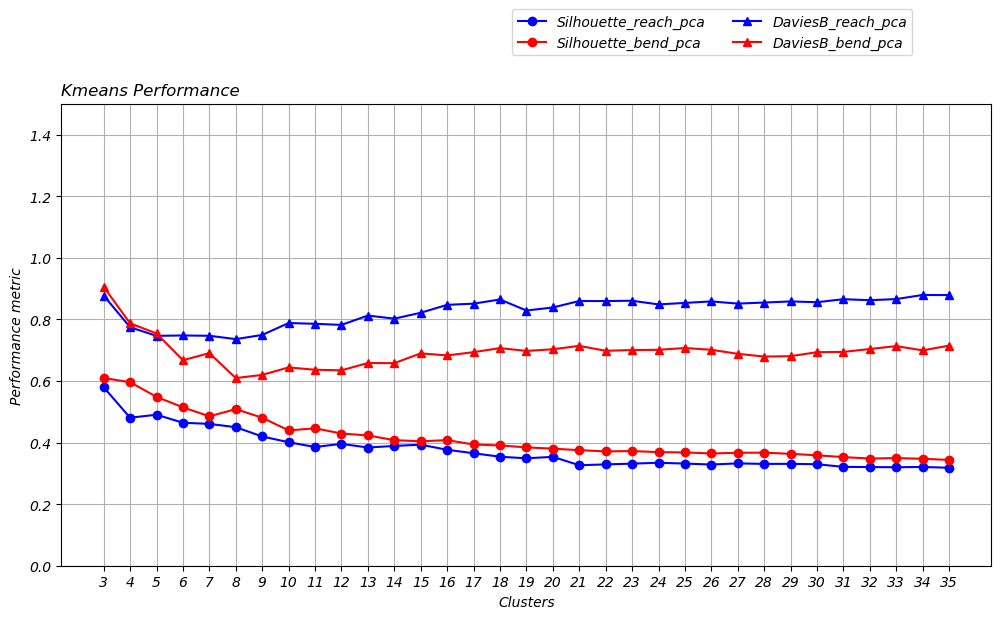

In [7]:
colors = ['blue', 'red', 'green', 'cyan']
marker = ['o', '^']
plt.figure(figsize = [12,6])
for i, s in enumerate(['Silhouette', 'DaviesB']):
    count = 0
    for j, rb in enumerate(['reach', 'bend']):
        for u, p in enumerate(['_pca']):
            if (rb == 'bend') & (p==''):
                continue
            
            plt.plot(dfKS['clusters'], dfKS[f'{s}_{rb}{p}'], marker = marker[i], 
                     label = f'{s}_{rb}{p}', color = colors[count])
            count +=1
    # plt.plot(dfKS['clusters'], dfKS[f'{s}'], marker = marker[i], label = f'{s}', color = colors[0])
plt.xticks(np.arange(dfKS['clusters'].min(),dfKS['clusters'].max()+1))
plt.ylim([0,1.5])
# plt.yticks(np.arange(0.35,1.5, 0.1))
plt.grid()
plt.title('Kmeans Performance', loc = 'left')
plt.legend(bbox_to_anchor = [0.7,1.22], ncols = 2, loc = 'upper center')
plt.xlabel('Clusters')
plt.ylabel('Performance metric')
plt.show()

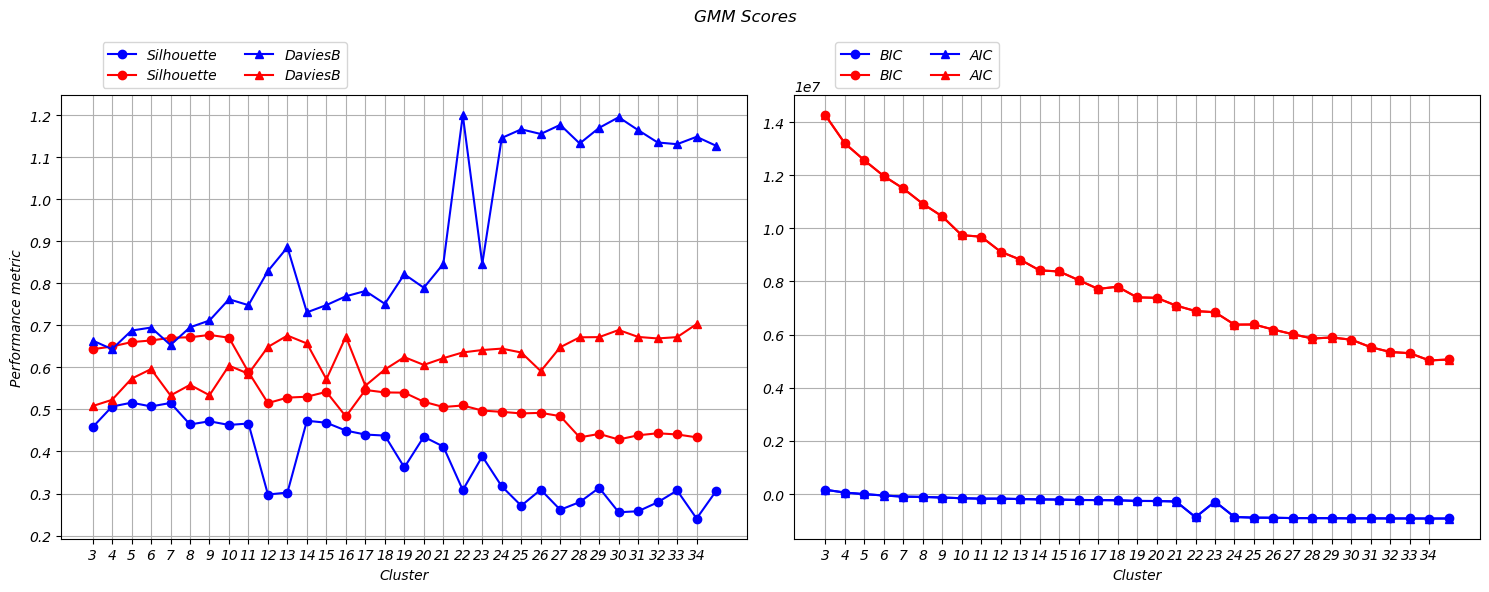

In [8]:
colors = ['blue', 'red', 'green']
marker = ['o', '^']
line = ['-', '--']
col = 0
f, ax = plt.subplots(ncols = 2, nrows = 1, figsize = [15,6])
for stI, st in enumerate([['Silhouette', 'DaviesB'], ['BIC', 'AIC']]):
    for i, s in enumerate(st):
        for ai, alg in enumerate(['tied']):
            for j, ch in enumerate(['reach', 'bend']):
                dfA = dfGS[dfGS['cov_type'] == alg]

                ax[stI].plot(dfA['clusters'], dfA[f'{s}_{ch}_pca'], marker = marker[i], label = f'{s}', color = colors[j], linestyle = line[ai])
            # dfA = dfGS[dfGS['cov_type'] == alg]
            # ax[stI].plot(dfA['clusters'], dfA[f'{s}'], marker = marker[i], label = f'{s}', color = colors[0], linestyle = line[ai])
    ax[stI].grid()
    ax[stI].set_xticks(np.arange(3,35))

    ax[stI].set_xlabel('Cluster')
    ax[stI].legend(bbox_to_anchor = [0.05,1], ncols = 2, loc = 'lower left')
ax[0].set_ylabel('Performance metric')
# ax[0].set_ylim([0.4,1.8])
ax[0].set_yticks(np.arange(0.2,1.3, 0.1))
f.suptitle('GMM Scores')
plt.tight_layout()
plt.show()

In [103]:
dfHD.head()
# dfHD['min_cluster_size'].unique(), dfHD['min_samples'].unique()

,min_cluster_size,min_samples,DBCV_chebyshev_reach_pca,relVal_chebyshev_reach_pca,DBCV_canberra_reach_pca,relVal_canberra_reach_pca,DBCV_euclidean_reach_pca,relVal_euclidean_reach_pca,DBCV_manhattan_reach_pca,relVal_manhattan_reach_pca,DBCV_chebyshev_reach,relVal_chebyshev_reach,DBCV_canberra_reach,relVal_canberra_reach,DBCV_euclidean_reach,relVal_euclidean_reach,DBCV_manhattan_reach,relVal_manhattan_reach
0,25,5,NaN,0.172708,NaN,0.061143,NaN,0.160112,NaN,0.153711,NaN,0.156270,-0.930300,0.023543,NaN,0.155359,NaN,0.147499
1,25,10,NaN,0.140486,NaN,0.128584,NaN,0.123284,NaN,0.121063,NaN,0.120712,-0.919017,0.024247,NaN,0.089795,NaN,0.098818
2,25,20,NaN,0.052615,NaN,0.190576,NaN,0.046264,NaN,0.048630,NaN,0.134469,-0.933355,0.019244,NaN,0.625331,NaN,0.080611
3,50,5,NaN,0.153162,NaN,0.033377,NaN,0.162309,NaN,0.131423,0.019406,0.140869,-0.891630,0.022893,0.010216,0.126928,0.028348,0.172294
4,50,10,NaN,0.032063,NaN,0.110101,-0.438889,0.013883,NaN,0.036517,-0.230840,0.147210,-0.870564,0.023730,-0.147944,0.099836,-0.224316,0.094037


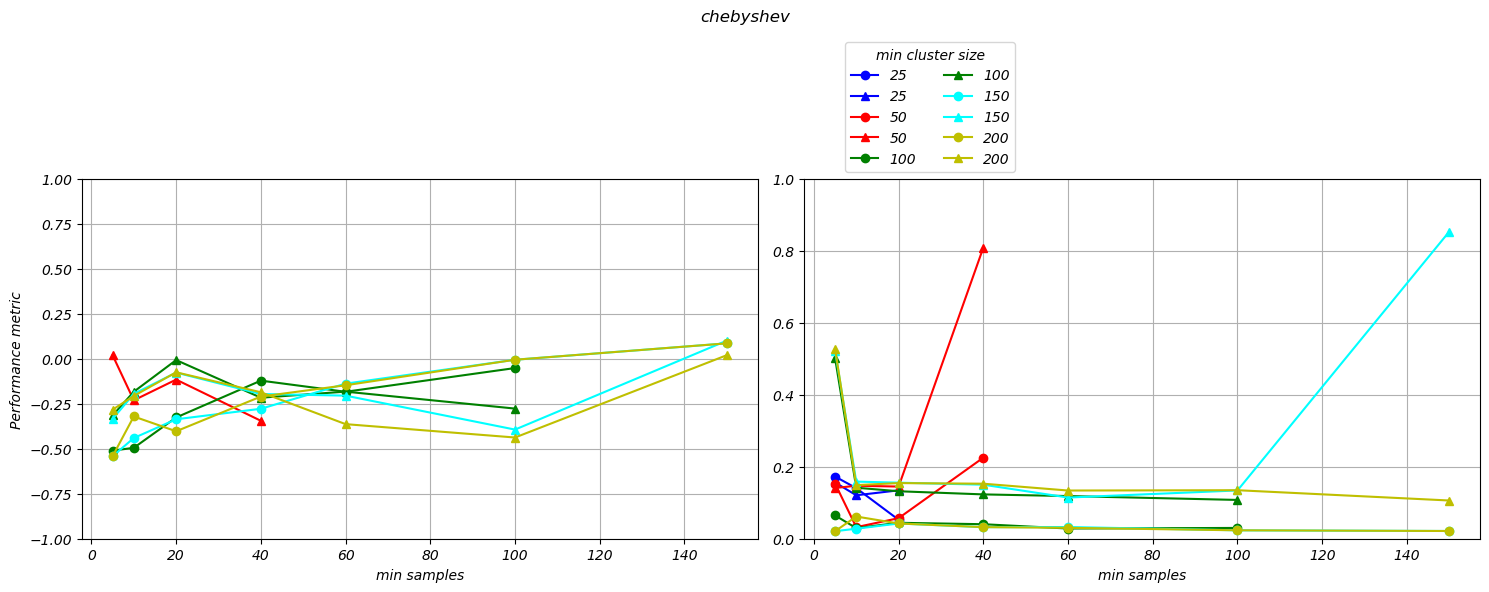

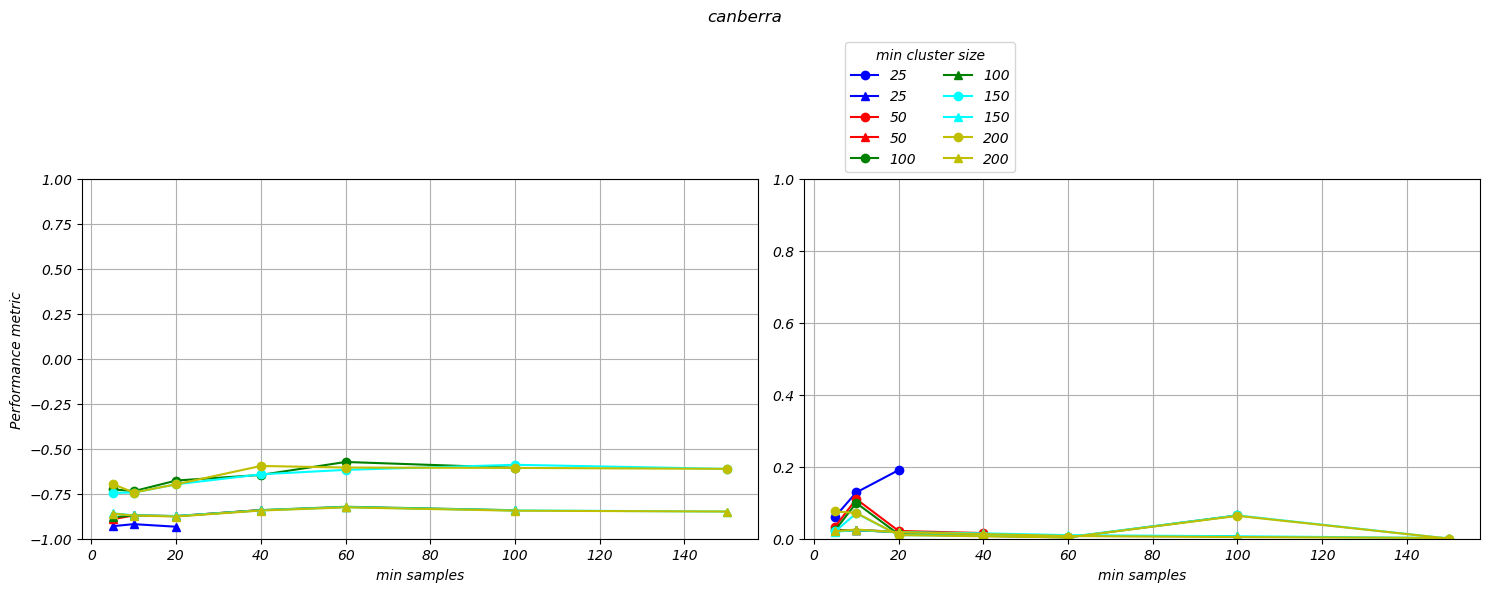

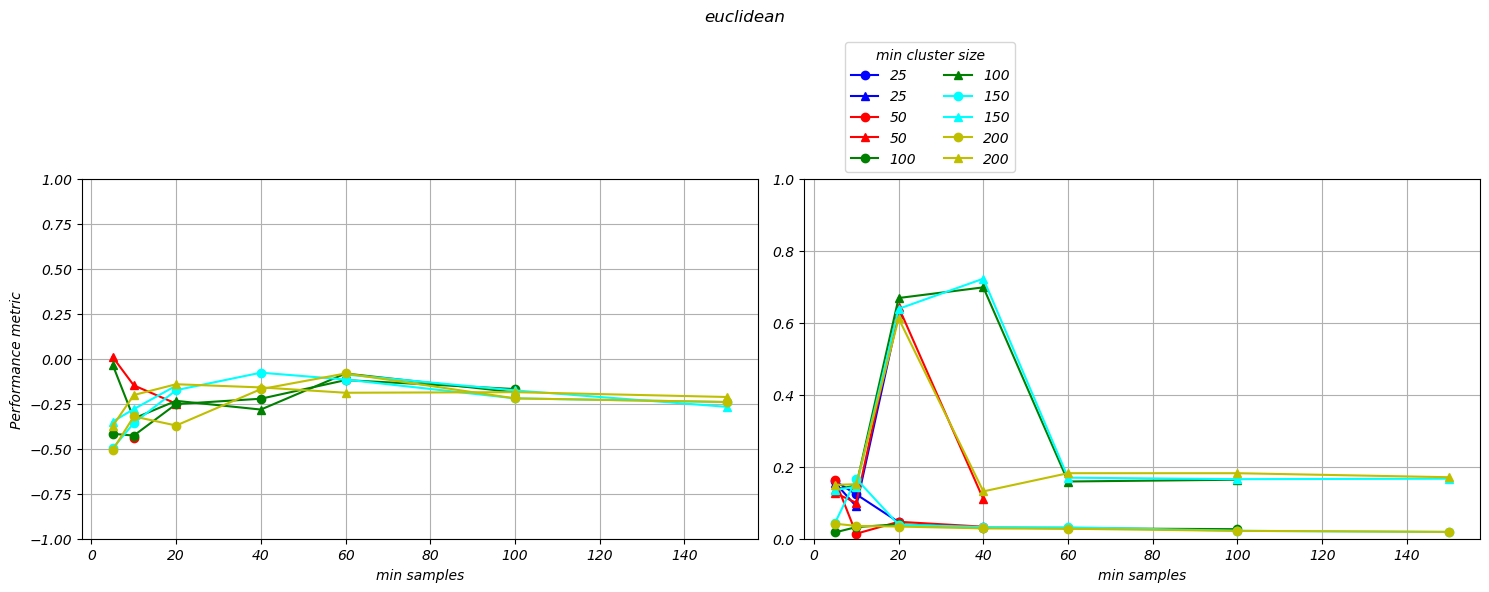

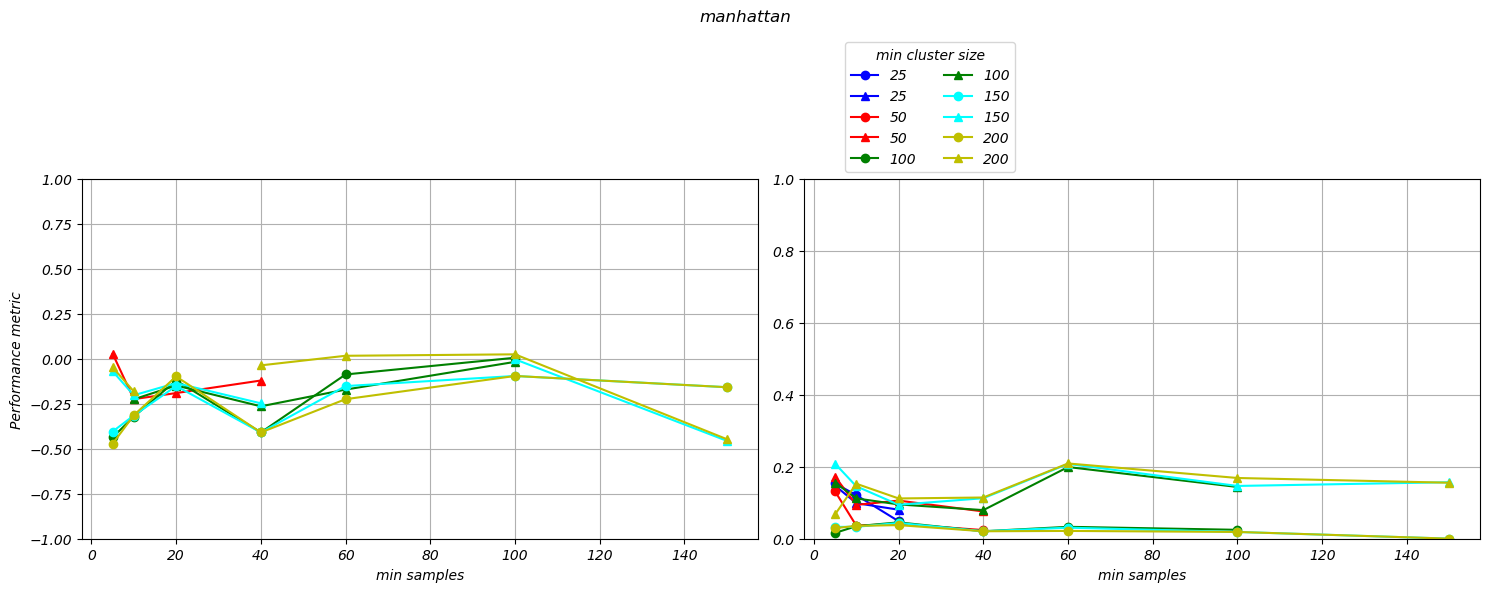

In [102]:
colors = ['blue', 'red', 'green', 'cyan', 'y']
marker = ['o', '^']
line = ['-', '--']
col = 0

for ai, alg in enumerate(['chebyshev', 'canberra', 'euclidean', 'manhattan']):
    f, ax = plt.subplots(ncols = 2, nrows = 1, figsize = [15,6])
    for stI, st in enumerate(['DBCV', 'relVal']):
        for i, s in enumerate(dfHD['min_cluster_size'].unique()):
            for j, ch in enumerate(['_pca', '']):
                dfA = dfHD[dfHD['min_cluster_size'] == s]

                ax[stI].plot(dfA['min_samples'], dfA[f'{st}_{alg}_reach{ch}'],
                              label = f'{s}',
                              marker = marker[j],
                              color = colors[i]) 
                            #   linestyle = line[ai])
            
        ax[stI].grid()
    
    # ax[stI].set_xticks(np.arange(3,35))

        ax[stI].set_xlabel('min samples')
    f.suptitle(alg)
    ax[stI].legend(bbox_to_anchor = [0.05,1], ncols = 2, loc = 'lower left', title = 'min cluster size')
    ax[0].set_ylabel('Performance metric')
    ax[0].set_ylim([-1,1])
    ax[1].set_ylim([0,1])
    # ax[0].set_yticks(np.arange(0.4,1.8, 0.1))
    # f.suptitle('GMM Scores')
    plt.tight_layout()
    plt.show()

# Open files

In [2]:
cross = 50

## create global bend

In [13]:
allResultFiles = np.sort(glob(directory + f'results/single_values/??_??_{cross}.csv'))
for i, f in tqdm(enumerate(allResultFiles), total = len(allResultFiles)):
    dfT = pd.read_csv(f)
    dfT['bendWidthRatio'] = dfT['bendMaxWidths'] / dfT['bendWidths']
    dfT['bendAng'] = dfT['ang']
    dfT['ang']     = dfT['bendAng'].mean()

    dfT['file_cont'] = f[-12:-10]
    dfT['file_id']   = f[-9:-7]
    if i == 0:
        df = dfT
    else:
        df = pd.concat([df, dfT], ignore_index=True)


100%|██████████| 43/43 [18:30<00:00, 25.83s/it]


In [20]:
dropCols = ['n_nodes','obstr_type', 'wse', 'lakeflag', 'swot_orbit', 'max_width', 'type','include_flag', 'pfaf1', 'pfaf2', 'node_mean_max_width',
            'combined_reach_len', 'combined_reach_width',
            'combined_reach_max_width','networkGroup', 'elevOut', 'elevInn', 'distOut', 'distInn',
            'lineOut', 'lineInn', 'LROrthog', 'lineSlope', 'bendHeight',
            'calculated',  'apexP','infP','grod_id', 'hfalls_id','localCRS','geometry', 'bendLines']
df = df.drop(dropCols, axis = 1)




In [15]:
ds = df.to_xarray()

# Build safe compression encoding
encoding = {}
for var in ds.data_vars:
    dtype = ds[var].dtype
    if dtype.kind in {"i", "u", "f"}:  # integer, unsigned, float
        encoding[var] = {"zlib": True, "complevel": 4,"chunksizes": (10000,)}
fileName = directory + f'results/single_values/global_{cross}.nc'
if os.path.exists(fileName):
    os.remove(fileName)
ds.to_netcdf(fileName, format="NETCDF4", encoding=encoding)


## create global single values netcdf

In [ ]:
allResultFiles = np.sort(glob(directory + f'results/single_values/??_??_{cross}.csv'))

In [ ]:
allResultFiles = np.sort(glob(directory + f'results/single_values/??_??_{cross}.csv'))
for i, f in tqdm(enumerate(allResultFiles), total = len(allResultFiles)):
    dfT = pd.read_csv(f)
    if i == 0:
        df = dfT
    else:
        df = pd.concat([df, dfT], ignore_index=True)

100%|██████████| 43/43 [15:52<00:00, 22.15s/it]


## Open global single values netcdf

In [35]:
subsetCols = ['sin', 'bendSin', 'ang', 'apex', 'bendAng', 'bendWidthRatio', 'widthRatio','bendWidths', 'combined_reach_id', 'file_cont', 'file_id']

In [10]:
f  = directory + 'results/single_values/global_50.nc'
ds = xr.open_dataset(f)

In [131]:
dfIn = ds.to_dataframe().reset_index()

In [132]:
dsSubset = ds[subsetCols]
dfIn = dsSubset.to_dataframe().reset_index()

In [164]:
dfIn['bendAng'] = abs(dfIn['bendAng'])
dfIn['ang']     = abs(dfIn['ang'])
dfIn['dimApex'] = dfIn['apex'] / dfIn['bendWidths']
dfIn['bendWidthRatio'] = 1 / dfIn['bendWidthRatio']
df = dfIn.copy()


### Fileter outliers

In [209]:
df = df[(df['bendSin'] < 6) & (df['dimApex'] < 35) & (df['bendAng'] < 0.1) & (df['bendWidthRatio'] > 0.02)]
# df = df[(df['bendAng'] < 1) & (df['ang'] < 1)]




In [104]:
# # found with cluster outlier detection
# # 5
# print(df.shape[0])
# df = df[(df['bendAng'] < 1000) & (df['bendAng'] > -500)]
# print(df.shape[0])

## Create reach averages

In [227]:
dfG = df.groupby(['file_cont', 'combined_reach_id'], as_index = False).agg({
    'file_id'   : 'first',
    'sin'       : 'first',
    'widthRatio': 'first',
    'dimApex'   : 'mean'  ,
    'ang'       : 'mean'    })

# Variables
- sin
- curv
- widthRatio
- apex

# Plot settings

In [16]:
labelSize = 15
tickSize  = 12

# Select and Normalize variables

#### Define FMP columns

In [211]:
FMPBendCols    = ['bendSin', 'dimApex', 'bendWidthRatio', 'bendAng']
FMPReachCols   = ['sin'    , 'dimApex', 'widthRatio'    , 'ang'    ]

#### Filter columns and drop NA values

In [212]:
dfBendCluster  = df.copy().dropna(subset = FMPBendCols )
dfReachCluster = dfG.copy().dropna(subset = FMPReachCols)

#### Scale filtered dataframe

In [213]:
def scale(df, scaleCols):
    X = df[scaleCols]
    # === Standardize features ===
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    return X_scaled


X_bend_scaled  = scale(dfBendCluster , FMPBendCols ) 
X_reach_scaled = scale(dfReachCluster, FMPReachCols)

# Apply Principle component analysis

#### Apply Principle Component analysis

In [214]:
pca_bend   = PCA(n_components=len(FMPBendCols))
X_bend_pca = pca_bend.fit_transform(X_bend_scaled)

pca_reach   = PCA(n_components=len(FMPReachCols))
X_reach_pca = pca_reach.fit_transform(X_reach_scaled)
print(f'{"Bend PCA explained:":<25}{pca_bend.explained_variance_ratio_}')
print(f'{"Reach PCA explained:":<25}{pca_reach.explained_variance_ratio_}')

numPCA = 4
pcaBendCols = [f'PCA{P}' for P in range(1,numPCA+1)]
dfBendCluster[pcaBendCols] = X_bend_pca[:, :numPCA]

pcaReachCols = [f'PCA{P}' for P in range(1,numPCA+1)]
dfReachCluster[pcaReachCols] = X_reach_pca[:, :numPCA]

Bend PCA explained:      [0.41810003 0.27388352 0.22217531 0.08584114]
Reach PCA explained:     [0.41437241 0.24979929 0.2239327  0.1118956 ]


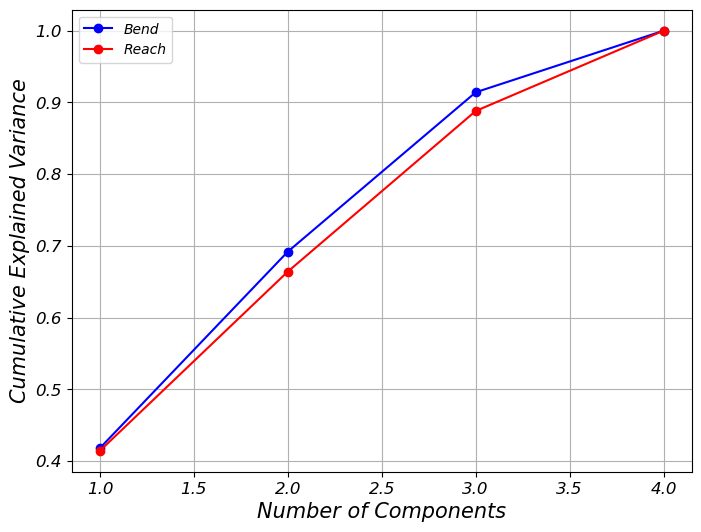

In [215]:
f, ax = plt.subplots(figsize = [8,6])
ax.plot(range(1, len(pca_bend.explained_variance_ratio_) + 1), 
         pca_bend.explained_variance_ratio_.cumsum(), marker='o', color = 'blue', label = 'Bend')
ax.plot(range(1, len(pca_reach.explained_variance_ratio_) + 1), 
         pca_reach.explained_variance_ratio_.cumsum(), marker='o', color = 'red', label = 'Reach')

ax.tick_params(axis='both', which='major', labelsize=tickSize)
plt.xlabel('Number of Components', fontsize = labelSize)
plt.ylabel('Cumulative Explained Variance', fontsize = labelSize)
# plt.annotate('97%', [6, 0.96956738], [8,0.8], arrowprops={'width':0.5, 'color':'black', 'shrink':0.05}, fontsize = 14)
plt.legend()
plt.grid(True)
plt.savefig(directory + 'results/figures/PCA_FMP.png')
plt.show()

#### Show variable loadings for PCA

In [216]:
# Suppose you have original feature names
def print_loadings(X, XS, pca):
    feature_names = X.columns if isinstance(X, pd.DataFrame) else [f"var{i}" for i in range(XS.shape[1])]

    # Create a DataFrame of loadings
    loadings = pd.DataFrame(
        data=pca.components_.T**2,
        index=feature_names,
        columns=[f"PC{i+1}" for i in range(pca.n_components_)]
    )

    print(loadings.round(3))
print('Bend Loadings')
print_loadings(dfBendCluster[FMPBendCols], X_bend_scaled, pca_bend)
print()
print('Reach Loadings')
print_loadings(dfReachCluster[FMPReachCols], X_reach_scaled, pca_reach)

Bend Loadings
                  PC1    PC2    PC3    PC4
bendSin         0.472  0.019  0.027  0.481
dimApex         0.310  0.261  0.088  0.341
bendWidthRatio  0.051  0.360  0.582  0.006
bendAng         0.167  0.359  0.302  0.172

Reach Loadings
              PC1    PC2    PC3    PC4
sin         0.434  0.000  0.061  0.505
dimApex     0.426  0.004  0.076  0.493
widthRatio  0.137  0.000  0.862  0.000
ang         0.003  0.995  0.000  0.002


# Outlier detection

### Distributions per var

In [163]:
10/2, 1/5

(5.0, 0.2)

In [162]:
dfIn['bendWidthRatio'].min(), dfIn['bendWidthRatio'].max()
dfIn['widthRatio'].min(), dfIn['widthRatio'].max()

(0.0053729257492764, 1.0)

In [192]:
dfIn[dfIn['bendSin'] > 6].shape[0], dfIn[dfIn['dimApex'] >35].shape[0], dfIn[dfIn['bendAng'] >0.1].shape[0], dfIn[dfIn['bendWidthRatio'] <0.02].shape[0]

# sin: <2.5
# dimApex:< 20
# ang: -
# widthRatio: >0.25


(234, 196, 341, 241)

In [173]:
dfT = dfIn[(dfIn['bendSin'] < 6) & (dfIn['dimApex'] < 35) & (dfIn['bendAng'] < 5) & (dfIn['bendWidthRatio'] > 0.02)]

In [181]:
dfT.shape[0], dfIn.shape[0], dfT.shape[0]- dfIn.shape[0], 750 / 1400000

(1489745, 1490496, -751, 0.0005357142857142857)

In [178]:
dfT[dfT['ang'] == dfT['ang'].max()][['ang', 'bendAng']]

,ang,bendAng
966712,3.394507e+11,0.002567
966713,3.394507e+11,0.005854
966714,3.394507e+11,0.004738
966715,3.394507e+11,0.003049
966716,3.394507e+11,0.003020
...,...,...
996953,3.394507e+11,0.002388
996954,3.394507e+11,0.002883
996955,3.394507e+11,0.000806
996956,3.394507e+11,0.002145


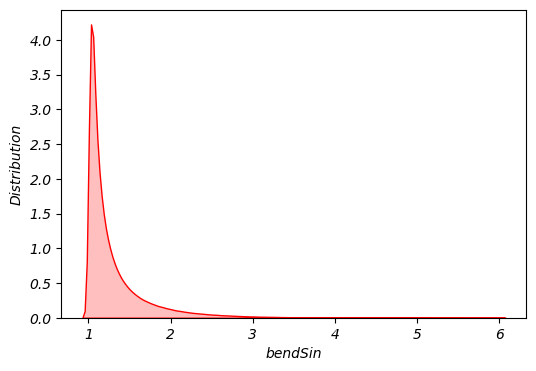

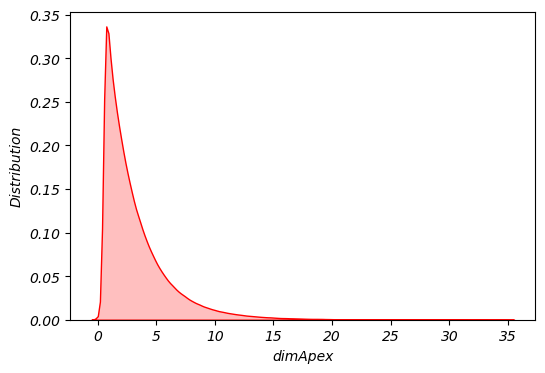

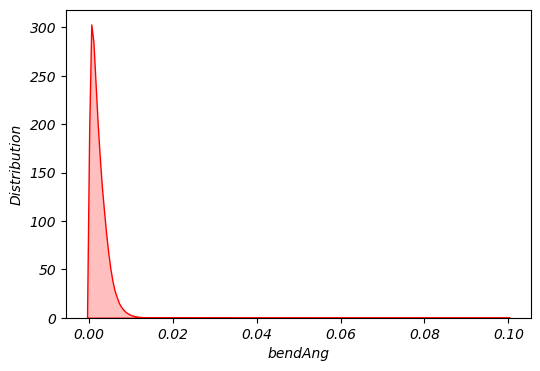

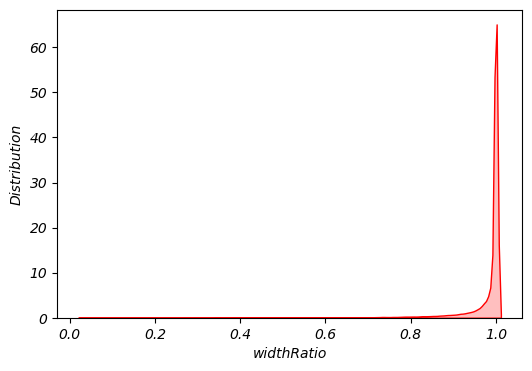

In [217]:
def kde_dist(df, cols):
     for col in cols:
        f, ax = plt.subplots(figsize = [6,4])
        sns.kdeplot(data = df, x = col, ax = ax, fill=True, color = 'red', legend = False)
        ax.set_xlabel(col)
        ax.set_ylabel('Distribution')
        plt.show()
kde_dist(df, ['bendSin', 'dimApex', 'bendAng', 'widthRatio'])

In [48]:
checkClusters = [3,4,5,6,7,8,9,10]

In [218]:
def add_labels(df,cols, clusters):

    kmeans = KMeans(n_clusters=clusters,init='k-means++',random_state=42)
    df[f'KMeans_pca_{clusters}']=  kmeans.fit_predict(df[cols])
    return df
for i in checkClusters:
    dfBendCluster = add_labels(dfBendCluster  , pcaBendCols , i)
    dfReachCluster = add_labels(dfReachCluster, pcaReachCols, i)



#### Check number of values per cluster
If single cluster exists with very few or single value probably outlier

In [219]:
for i in checkClusters:
    N,U = np.unique(dfBendCluster[f'KMeans_pca_{i}'], return_counts=True)
    print(f"{i:<2}", f'{str(list(N)):<30}', list(U))


3  [0, 1, 2]                      [1098019, 312346, 79128]
4  [0, 1, 2, 3]                   [955503, 271302, 78108, 184580]
5  [0, 1, 2, 3, 4]                [864037, 265386, 77409, 70334, 212327]
6  [0, 1, 2, 3, 4, 5]             [772537, 72418, 77103, 51755, 286735, 228945]
7  [0, 1, 2, 3, 4, 5, 6]          [650780, 251040, 76711, 66217, 45664, 314039, 85042]
8  [0, 1, 2, 3, 4, 5, 6, 7]       [695462, 249911, 76836, 27812, 107691, 269927, 2207, 59647]
9  [0, 1, 2, 3, 4, 5, 6, 7, 8]    [604912, 77834, 76440, 29176, 112260, 226256, 1002, 48887, 312726]
10 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] [572177, 127657, 76303, 14681, 54245, 207939, 1013, 53609, 300292, 81577]


In [220]:
for i in checkClusters:
    N,U = np.unique(dfReachCluster[f'KMeans_pca_{i}'], return_counts=True)
    print(f"{i:<2}", f'{str(list(N)):<30}', list(U))

3  [0, 1, 2]                      [7306, 96041, 37227]
4  [0, 1, 2, 3]                   [7124, 94293, 36347, 2810]
5  [0, 1, 2, 3, 4]                [6781, 47812, 12544, 2809, 70628]
6  [0, 1, 2, 3, 4, 5]             [6648, 47526, 16505, 2809, 60468, 6618]
7  [0, 1, 2, 3, 4, 5, 6]          [6605, 43200, 15153, 2808, 54881, 3356, 14571]
8  [0, 1, 2, 3, 4, 5, 6, 7]       [2334, 14884, 2801, 53540, 3334, 39612, 9695, 14374]
9  [0, 1, 2, 3, 4, 5, 6, 7, 8]    [2314, 13186, 2800, 41484, 7242, 40336, 9500, 21367, 2345]
10 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9] [1186, 12954, 2799, 39948, 7180, 39205, 3889, 21183, 2295, 9935]


#### Plot variables against each other to see problamatic variable

In [157]:
dfOut = dfBendCluster[dfBendCluster['KMeans_pca_7'] == 2]

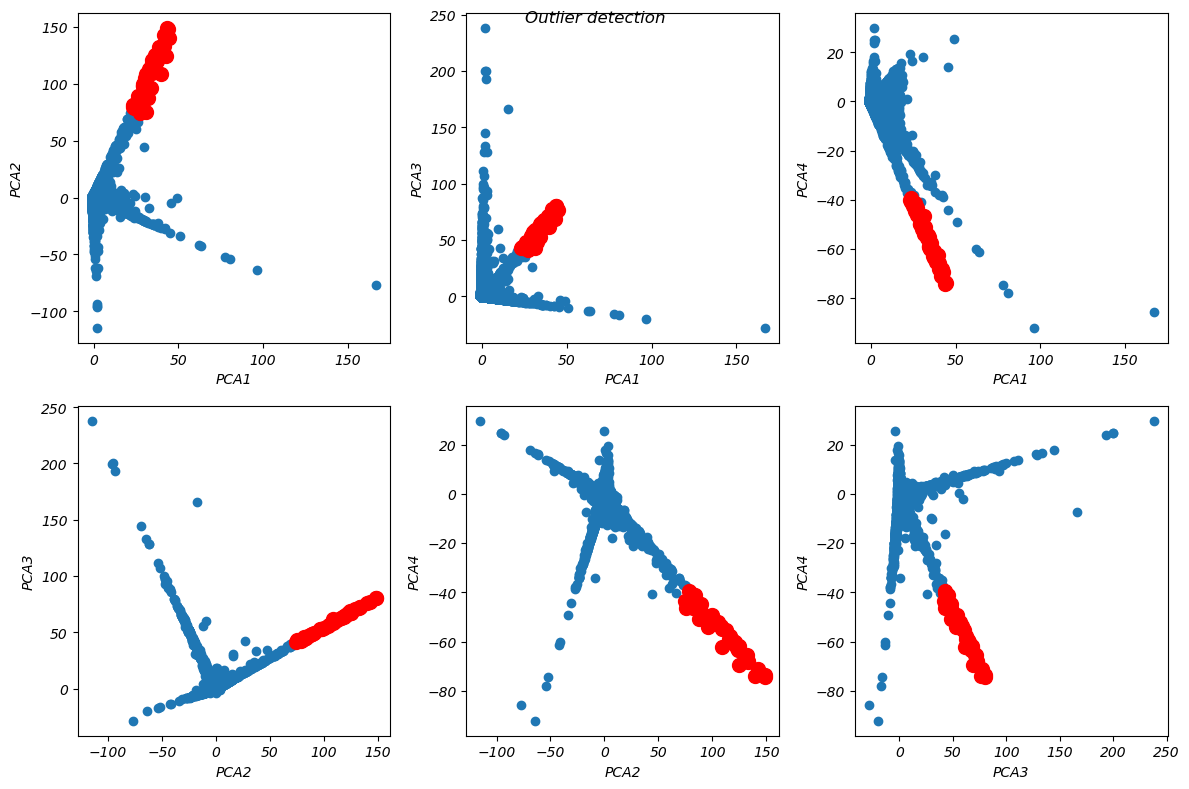

In [126]:
f, ax = plt.subplots(ncols = 3, nrows = 2, figsize = [12,8])
x = ['PCA1', 'PCA1', 'PCA1', 'PCA2', 'PCA2', 'PCA3']
y = ['PCA2', 'PCA3', 'PCA4', 'PCA3', 'PCA4', 'PCA4']
C, R = -1,0
for i in range(6):
    # print(i, R, C)
    if i == 3:

        R += 1
        C  = 0
    else:

        C += 1

    ax[R,C].scatter(dfBendCluster[x[i]], dfBendCluster[y[i]])
    ax[R,C].scatter(dfOut[x[i]], dfOut[y[i]], s = 100, c = 'red')
    ax[R,C].set_xlabel(x[i])
    ax[R,C].set_ylabel(y[i])
    
plt.tight_layout()
f.suptitle('Outlier detection')
plt.show()

In [153]:
dfG['ang'].max(), df['bendAng'].max()

(0.03750743667489536, 0.96677103)

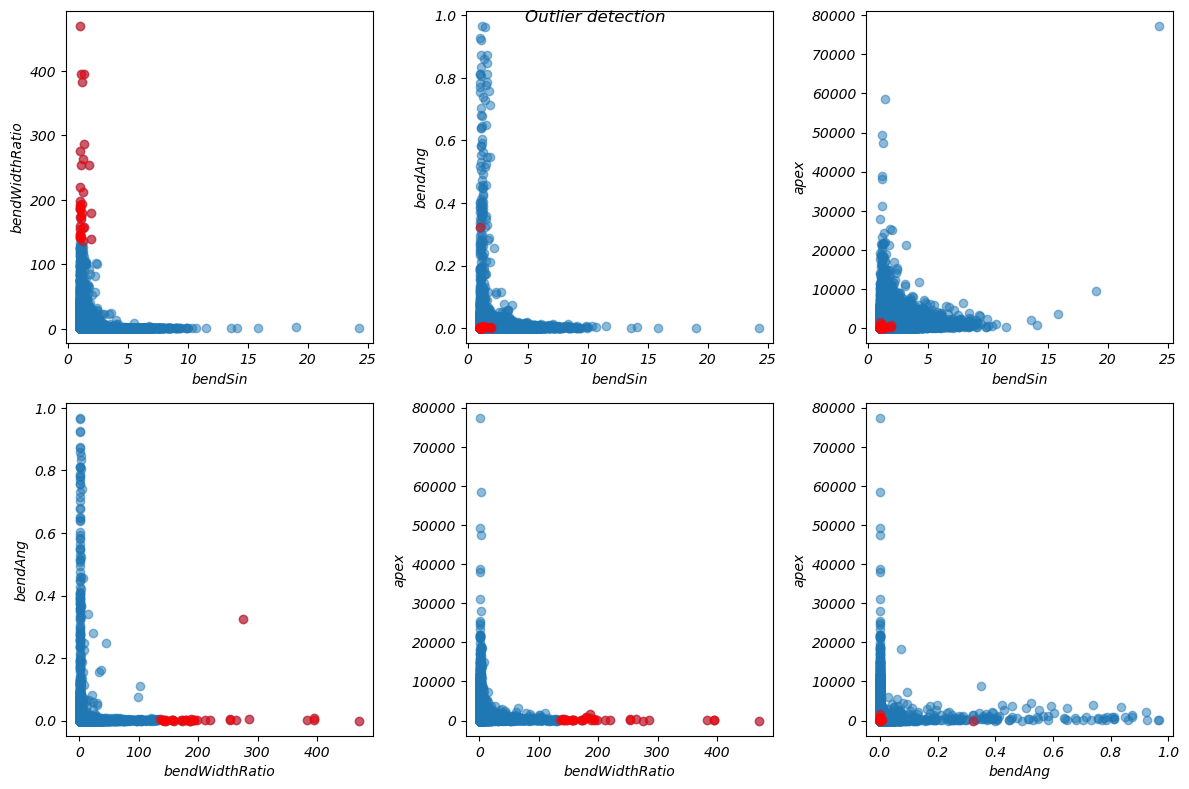

In [158]:
f, ax = plt.subplots(ncols = 3, nrows = 2, figsize = [12,8])
x = ['bendSin', 'bendSin', 'bendSin', 'bendWidthRatio', 'bendWidthRatio', 'bendAng']
y = ['bendWidthRatio', 'bendAng', 'apex', 'bendAng', 'apex', 'apex']
C, R = -1,0
for i in range(6):
    # print(i, R, C)
    if i == 3:

        R += 1
        C  = 0
    else:

        C += 1

    ax[R,C].scatter(dfBendCluster[x[i]], dfBendCluster[y[i]], alpha = 0.5)
    ax[R,C].scatter(dfOut[x[i]], dfOut[y[i]], c = 'red', alpha = 0.5)
    ax[R,C].set_xlabel(x[i])
    ax[R,C].set_ylabel(y[i])
    
plt.tight_layout()
f.suptitle('Outlier detection')
plt.show()

# Functions

In [69]:
def bar_cluster_distribution_plot(df, C, cols):

    f,ax =plt.subplots(ncols = len(cols), nrows = 1, squeeze = False, figsize = [15,7], sharey =True)
    
    for i in range(len(cols)):
        if cols[i] == '':
            col = f'{C}'
        else:
            col = f'{C}_{cols[i]}'

        values                = df[col]
        unique_labels, counts = np.unique(values, return_counts=True)

        # Optional: sort clusters by label
        sorted_indices = np.argsort(unique_labels)
        unique_labels  = unique_labels[sorted_indices]
        counts         = counts[sorted_indices]


        ax[0,i].bar([str(lbl) for lbl in unique_labels], counts, color='skyblue', edgecolor='black')
        # ax[0,i].set_yticks(np.arange(0, 1.2e6, 5e4))
        ax[0,i].set_xlabel("Cluster Label")
        
        ax[0,i].set_title(cols[i])
        ax[0,i].grid(axis='y', linestyle='--', alpha=0.7)
        # ax[0,i].set_ylim(0,950000)
    ax[0,0].set_ylabel("Number of Samples")
    plt.tight_layout()

    plt.show()
    


In [75]:
def plot_kde_cluster(df, cols, clustering,clusters):
    if (len(cols) %2) == 0:
        ncols = 2
        nrows = int(len(cols) /2)
    else:
        ncols = 3
        nrows = int(len(cols) /3)

    colRange = [[1,2], [0,0.04], [0,15], [0.1,1.1]]
    for c in range(clusters):
        f, axs = plt.subplots(nrows = nrows, ncols = ncols, figsize = [15, 8])
        count = 0
        for i in range(nrows):
            for j in range(ncols):
                data = df[df[clustering] == c]
                L = sns.kdeplot(data = data, x = cols[count], ax=axs[i,j], fill=True, color = 'red', legend = False)

                
                axs[i,j].set_xlabel(cols[count], fontsize = 10)
                axs[i,j].grid(True, which="both", ls="--", lw=0.5)
                axs[i,j].tick_params(axis='both', which='major', labelsize=tickSize)
                # axs[i,j].set_ylim([0,0.06])
                axs[i,j].set_xlim(colRange[count])
                # axs[i,j].set_xticks(np.arange(0,1.1,0.1))
            
            
                count +=1
        f.suptitle(f'Number of clusters: {clusters}, cluster: {c}')
        # plt.savefig(directory + f'results/figures/KDE_{clusters}_{clusterVal}_{CH}.png')
        plt.show()

# Kmeans clustering

## Elbow Curve

In [76]:
def kmeans_elbow(X, k):
    # === Elbow Method to determine optimal k ===
    inertia = []
    k_range = range(1, k)

    
    for mi in [300]:
        for n_init in [5]:
            inter = []
            for k in tqdm(k_range):
                kmeans = KMeans(n_clusters   = k,
                                init         = 'k-means++',
                                random_state = 42,
                                max_iter     = mi)
                kmeans.fit(X)
                inter.append(kmeans.inertia_)  # Sum of squared distances to closest cluster center
            inertia.append(inter)
    return k_range, inertia




In [143]:
vars = [X_bend_scaled, dfBendCluster[pcaBendCols], X_reach_scaled, dfReachCluster[pcaReachCols]]
krL, inL = [], []
for i in range(len(vars)):
    kr   ,  inertia      = kmeans_elbow(vars[i] , 25)
    krL.append(kr)
    inL.append(inertia)

# krPCA,  inertiaPCA   = kmeans_elbow(dfCluster[clusterCols] , 25)

100%|██████████| 24/24 [02:10<00:00,  5.42s/it]


No difference between different max_iter and n_init settings to stick to default

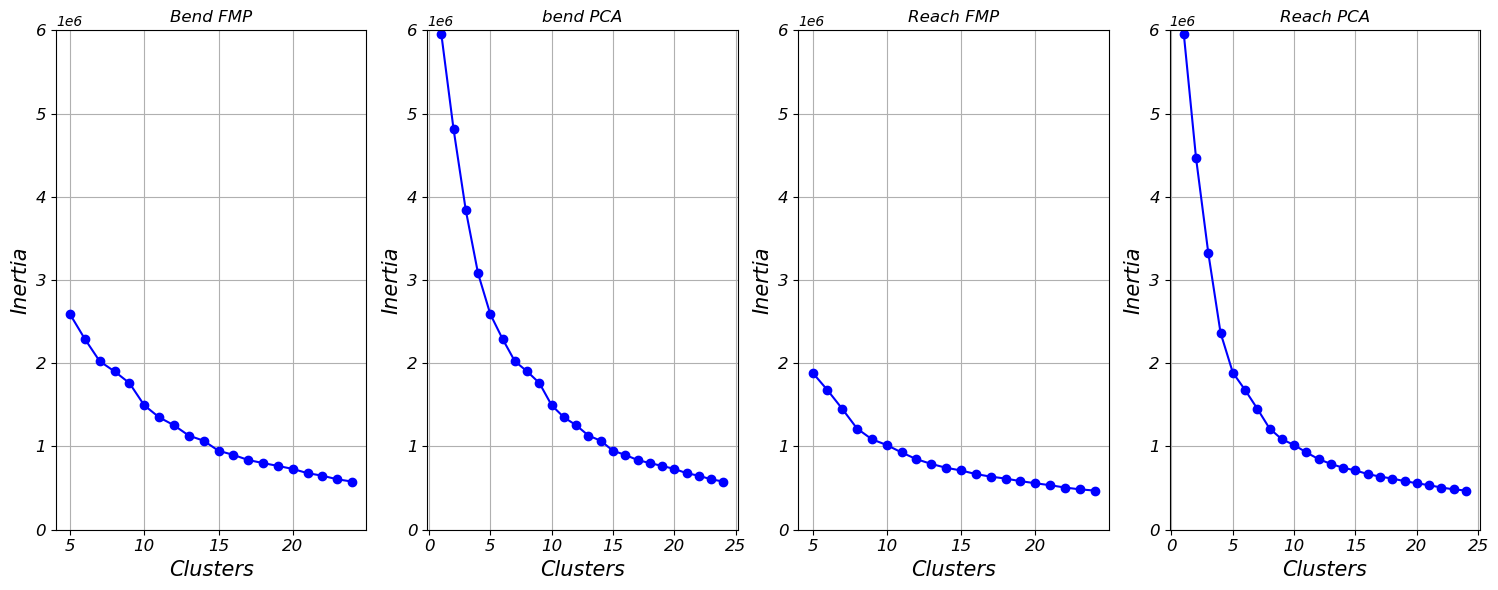

In [147]:
f, ax = plt.subplots(ncols = 4, figsize = [15,6], squeeze = False)
titles = ['Bend FMP', 'bend PCA', 'Reach FMP', 'Reach PCA']
for i in range(4):
    K  = krL[i]
    IN = inL[i]
    for I in IN:
        if (i == 0) | (i == 2):
            K = K[4:]
            I = I[4:]
        ax[0,i].plot(K, I, marker = 'o', color = 'blue')
        ax[0,i].grid()
        ax[0,i].tick_params(axis='both', which='major', labelsize=tickSize)
        ax[0,i].set_xlabel('Clusters', fontsize = labelSize)
        ax[0,i].set_ylabel('Inertia' , fontsize = labelSize)
        ax[0,i].set_title(titles[i])
        ax[0,i].set_ylim([0,6e6])
plt.tight_layout()
plt.show()

## Silhouette score
Apply on smaller number of centroids since it is computationally expensive

In [181]:
def resampleSilhouette(algo, X, sampleSize,random_state =42, printScore = False):

    labels             = algo.fit_predict(X)
    if X.shape[0] < sampleSize:
        sampleSize = X.shape[0]
    lab, labCounts = np.unique(labels,return_counts=True)
    # print(labCounts)
    if all(labCounts>10):
        # print(X, labels)
        X_sample, y_sample = resample(X, labels, n_samples=sampleSize, random_state=random_state)
        silScore           = silhouette_score(X_sample, y_sample)
        davScore           = davies_bouldin_score(X_sample, y_sample)
    else:
        silScore, davScore = np.nan, np.nan
    if printScore == True:
        print(f"Silhouette Score (sample size-{sampleSize}, random_state-{random_state}):", np.round(silScore,3), np.round(davScore, 3))
    return silScore, davScore

In [6]:
import numpy as np

A = np.array([0,0,1,1,3,3,4,4])
_, B = np.unique(A, return_counts=True)

np.nanmean([np.nan,np.nan])

/tmp/ipykernel_158406/2712792804.py:6: RuntimeWarning: Mean of empty slice
  np.nanmean([np.nan,np.nan])


nan

In [185]:

sampleSize = 50000
clusters = [3,4,5, 6,7,8 ,9,10,11,12, 13, 14, 15, 20, 30]
# clusters = [3]
vars = [X_bend_scaled, dfBendCluster[pcaBendCols[0:1]], X_reach_scaled, dfReachCluster[pcaReachCols]]
varScoreSil, varScoreDav = [], []
for var in vars:
    silScore, davScore = [], []
    for i,c in enumerate(clusters):
        print(c)
        sL, dL = [], []
        for rs in [43, 50 ,60]:
            kmeans = KMeans(n_clusters=c,init='k-means++',random_state=rs)
            

            s, d = resampleSilhouette(kmeans, var  , sampleSize, rs,False)
            sL.append(s)
            dL.append(d)
        
        silScore.append(np.mean(sL))
        davScore.append(np.mean(dL))
        # print(sL, s, silScore)
        print(f"Silhouette Score (sample size-{sampleSize}, random_state-{rs}):", np.round(silScore[i],15), np.round(davScore[i], 15))
    varScoreSil.append(silScore)
    varScoreDav.append(davScore)
    print()

3
Silhouette Score (sample size-50000, random_state-60): 0.731876776204088 0.805949294816057
4
Silhouette Score (sample size-50000, random_state-60): 0.608966044597722 0.765552396618688
5
Silhouette Score (sample size-50000, random_state-60): 0.557774982597755 0.777195280741393
6
Silhouette Score (sample size-50000, random_state-60): 0.511544775309122 0.74879899734522
7
Silhouette Score (sample size-50000, random_state-60): 0.481205985871915 0.766653334156242
8
Silhouette Score (sample size-50000, random_state-60): 0.503303399550323 0.646982889885603
9
Silhouette Score (sample size-50000, random_state-60): 0.477444974568664 0.673945265829924
10
Silhouette Score (sample size-50000, random_state-60): 0.466153943932258 0.670026423603788
11
Silhouette Score (sample size-50000, random_state-60): 0.467876106639614 0.656880808364032
12
Silhouette Score (sample size-50000, random_state-60): 0.425501323566038 0.668939738328953
13
Silhouette Score (sample size-50000, random_state-60): nan nan
14

In [1]:
# plt.plot(clusters, davScore, marker = 'o', color = 'blue', label = 'Davies Bouldin')
# plt.plot(clusters, silScore, marker = 'o', color = 'red', label = 'Silhouette')
# plt.yticks(np.arange(0.2,1.4,0.1))
# plt.legend()
# plt.show()

## Cluster distribution

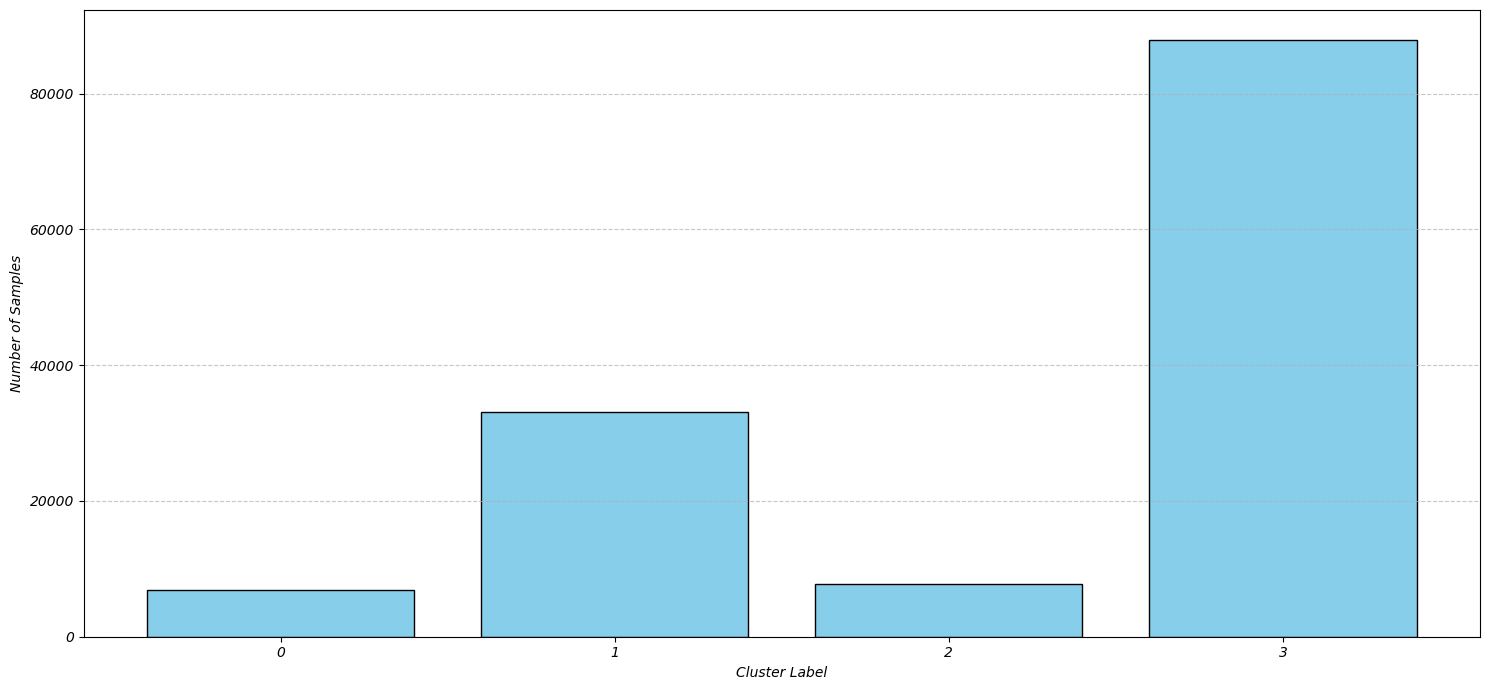

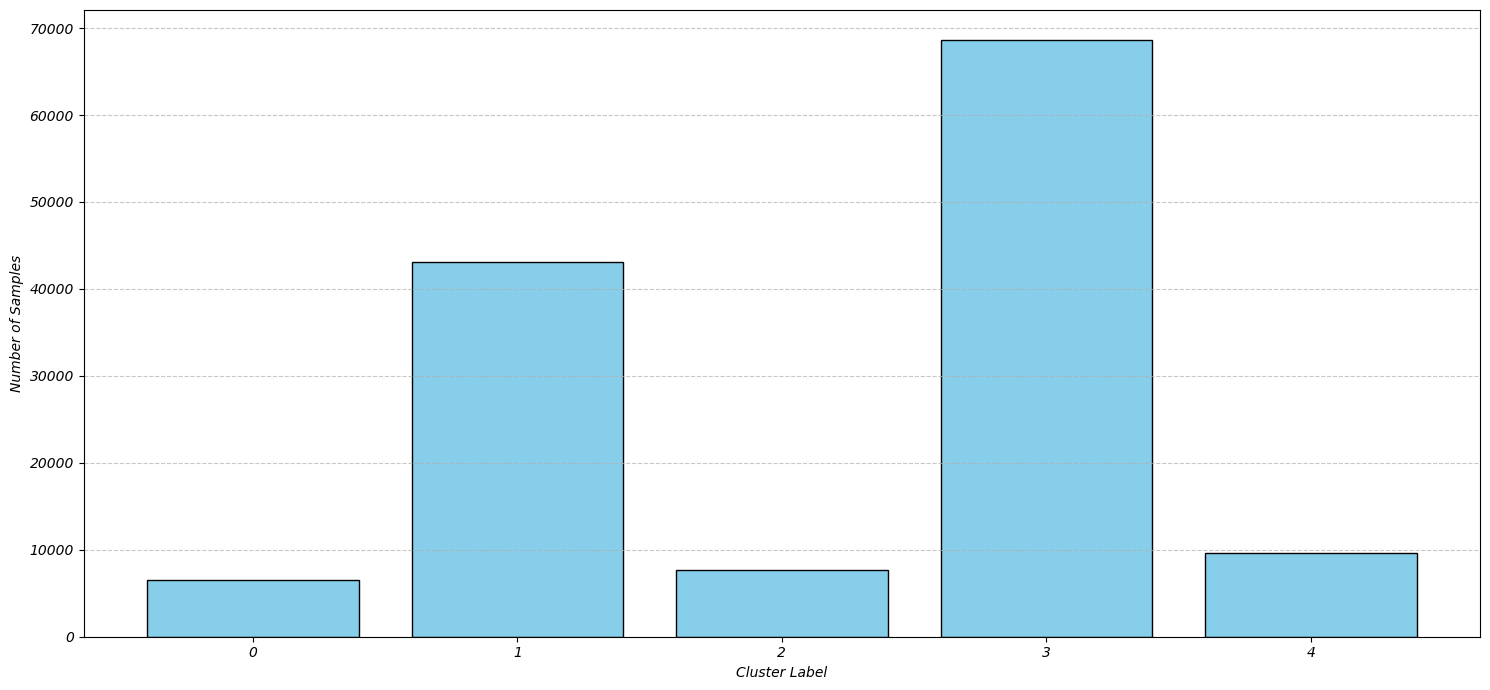

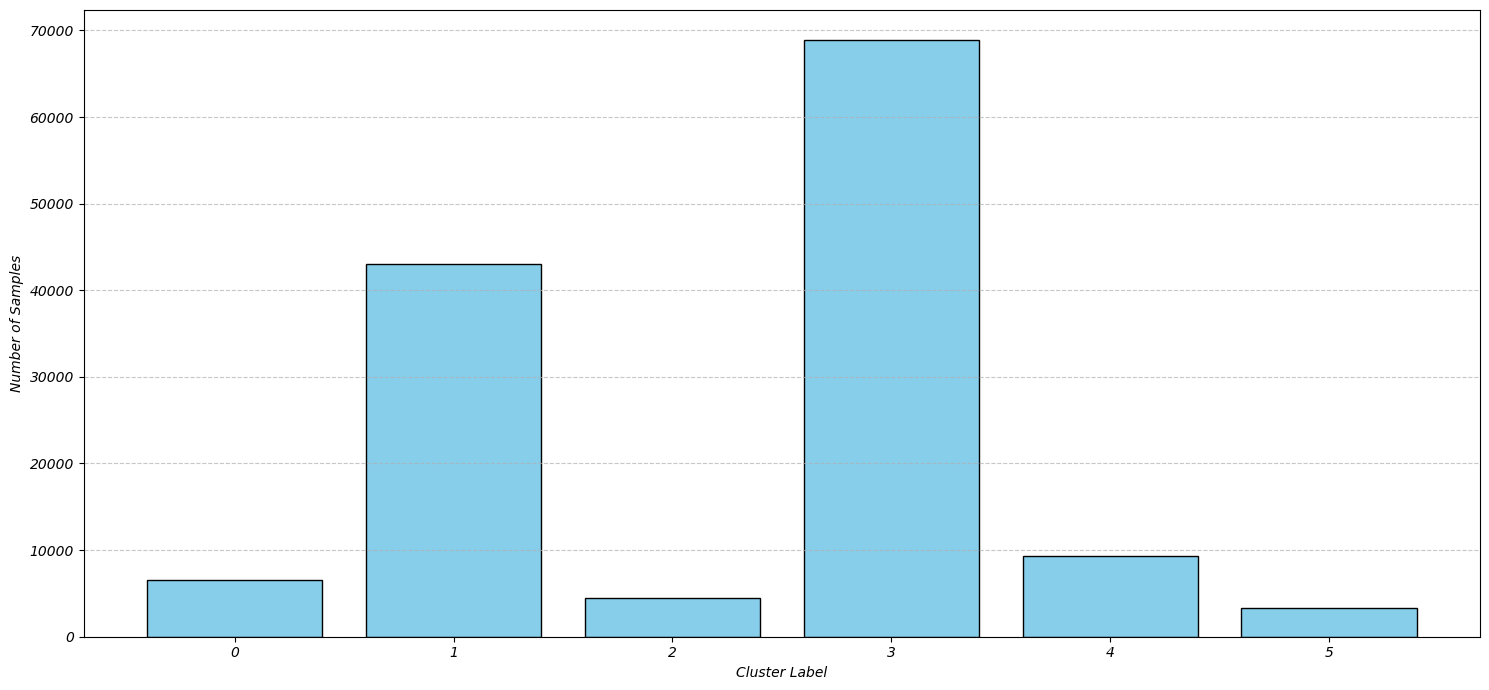

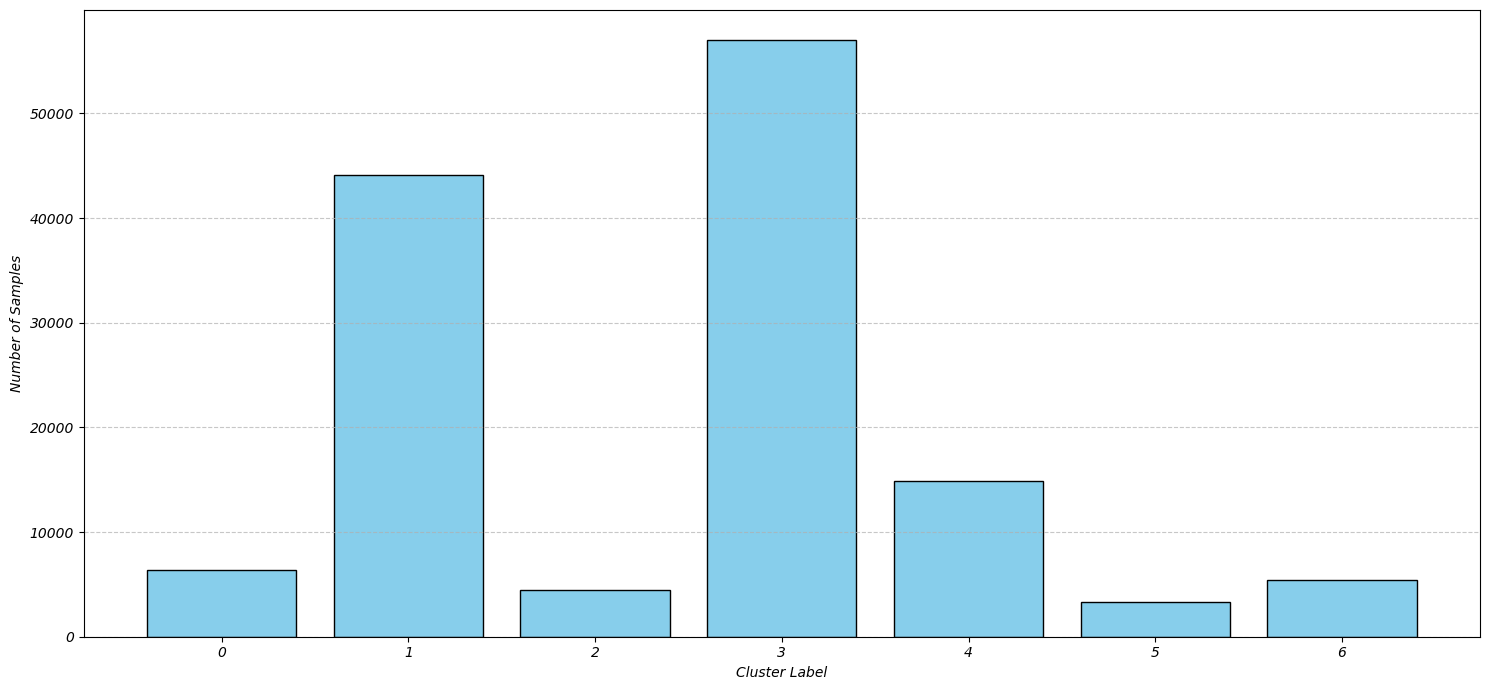

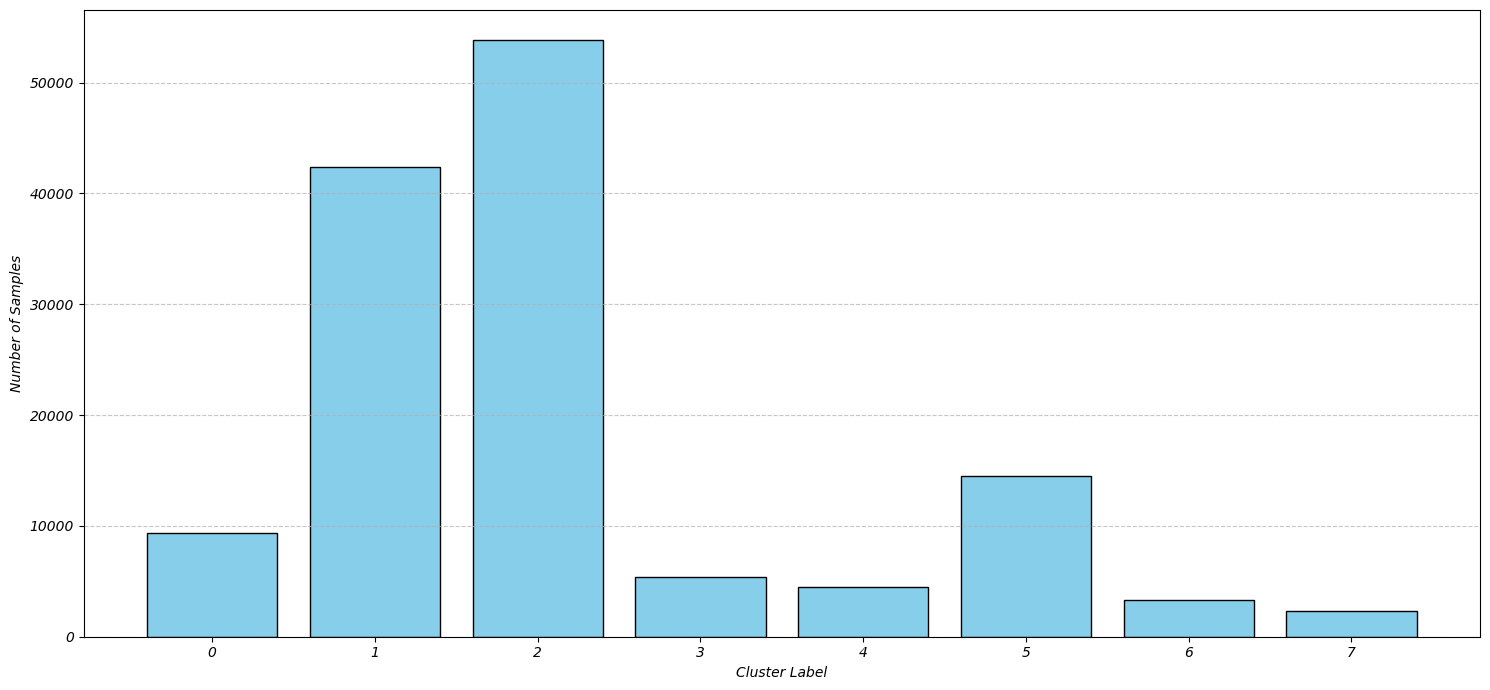

In [68]:
bar_cluster_distribution_plot(dfReachCluster,'KMeans_pca_4', [''])
bar_cluster_distribution_plot(dfReachCluster,'KMeans_pca_5', [''])
bar_cluster_distribution_plot(dfReachCluster,'KMeans_pca_6', [''])
bar_cluster_distribution_plot(dfReachCluster,'KMeans_pca_7', [''])
bar_cluster_distribution_plot(dfReachCluster,'KMeans_pca_8', [''])


## KDE per cluster

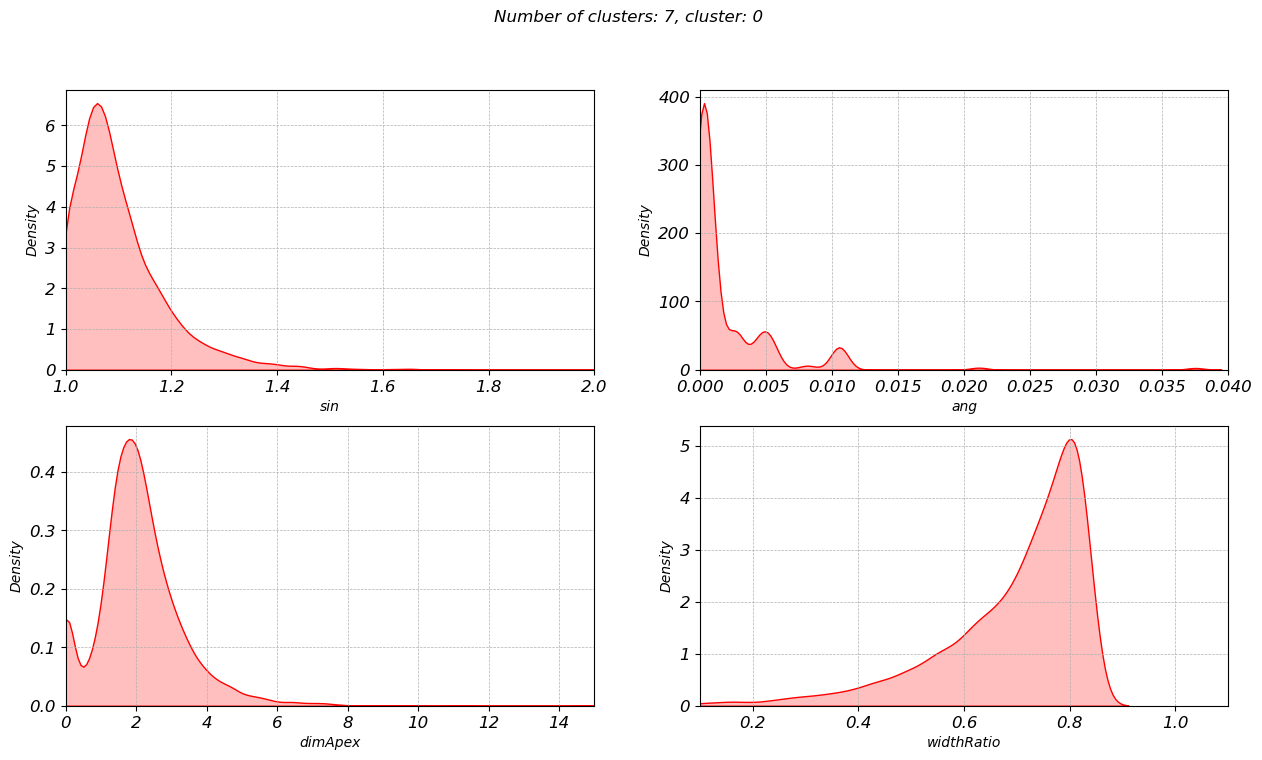

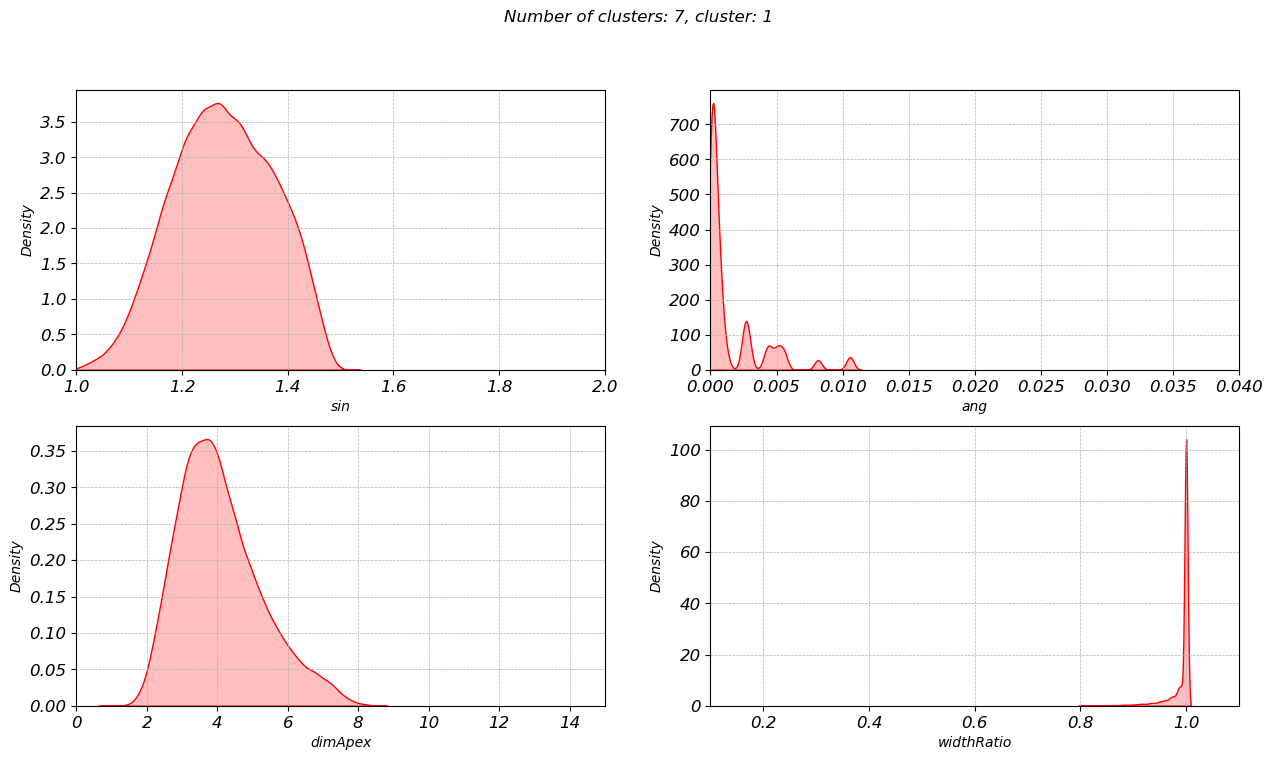

/tmp/ipykernel_22598/4094632623.py:16: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  L = sns.kdeplot(data = data, x = cols[count], ax=axs[i,j], fill=True, color = 'red', legend = False)


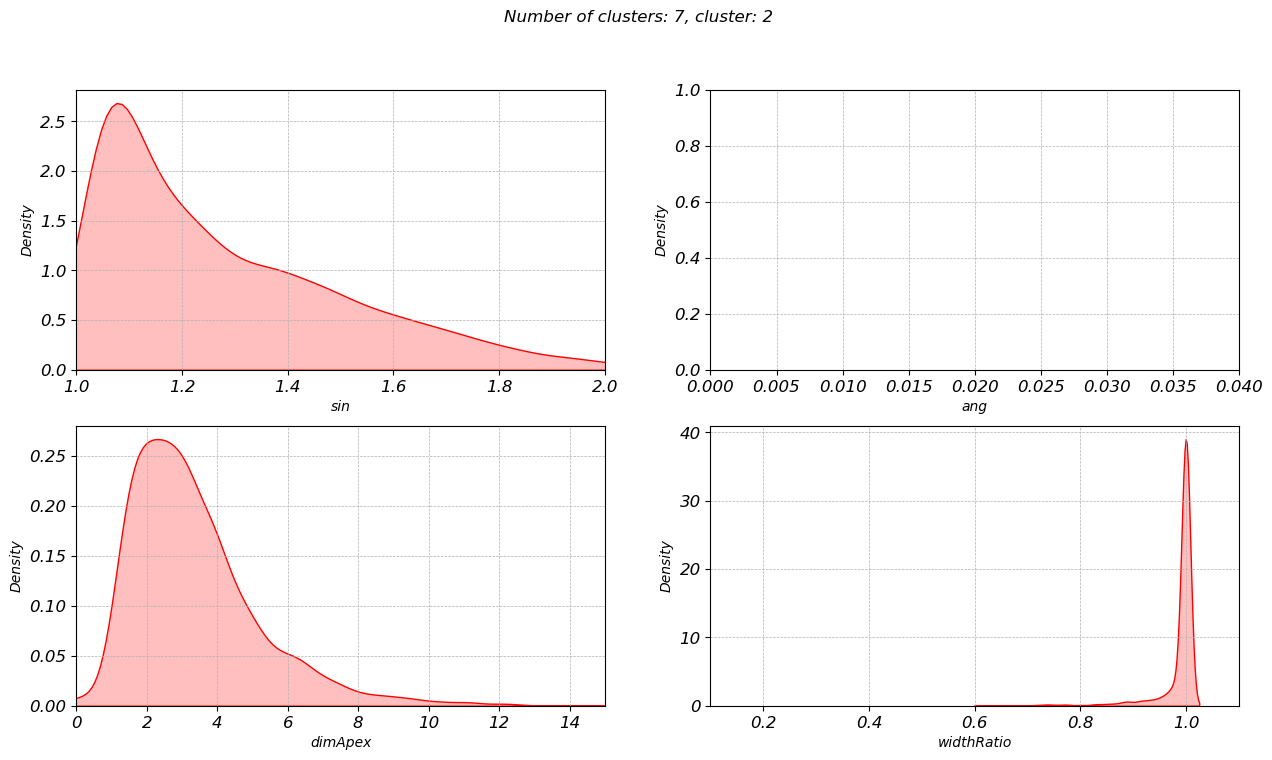

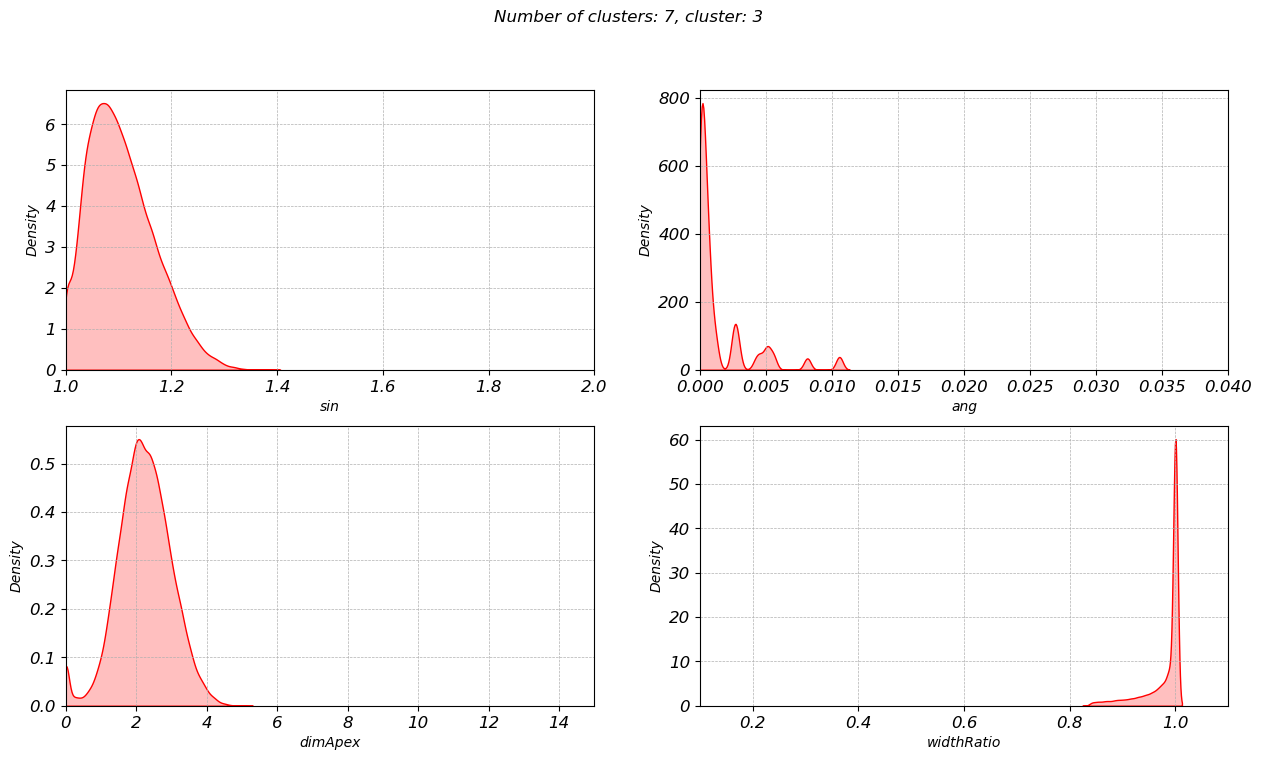

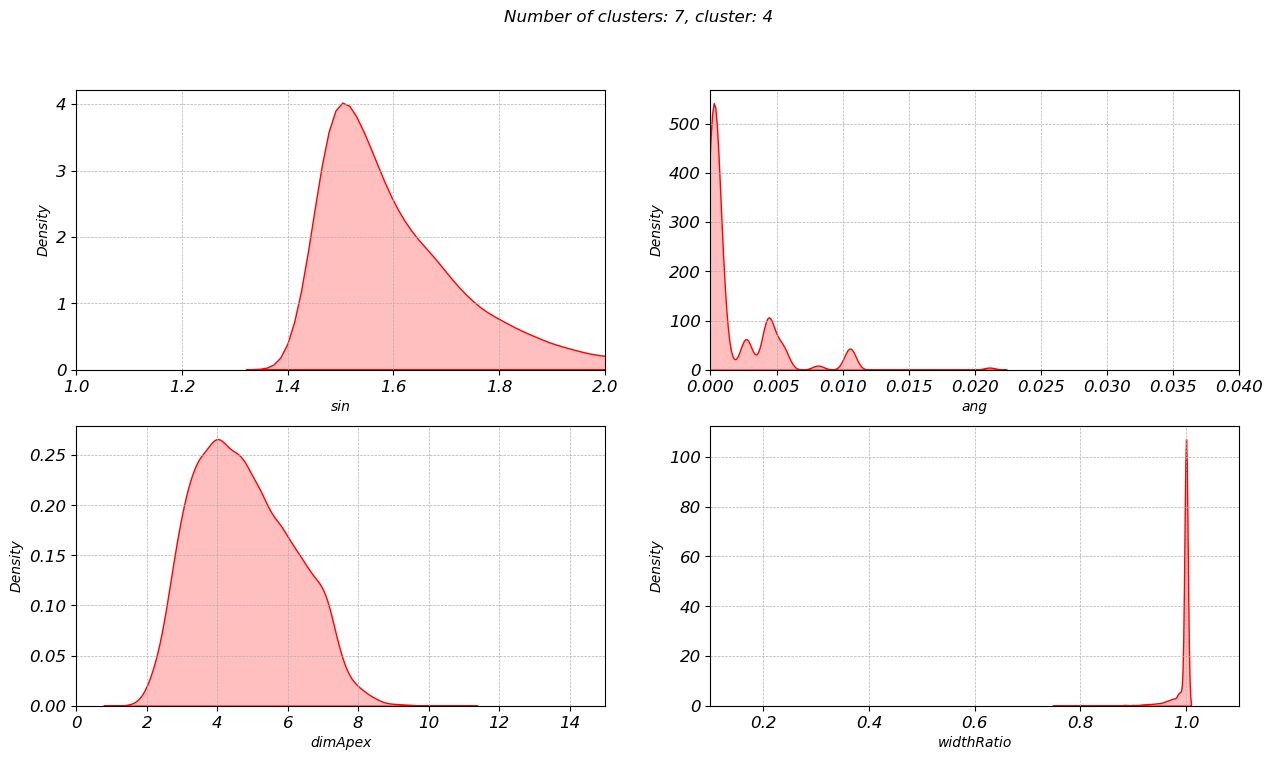

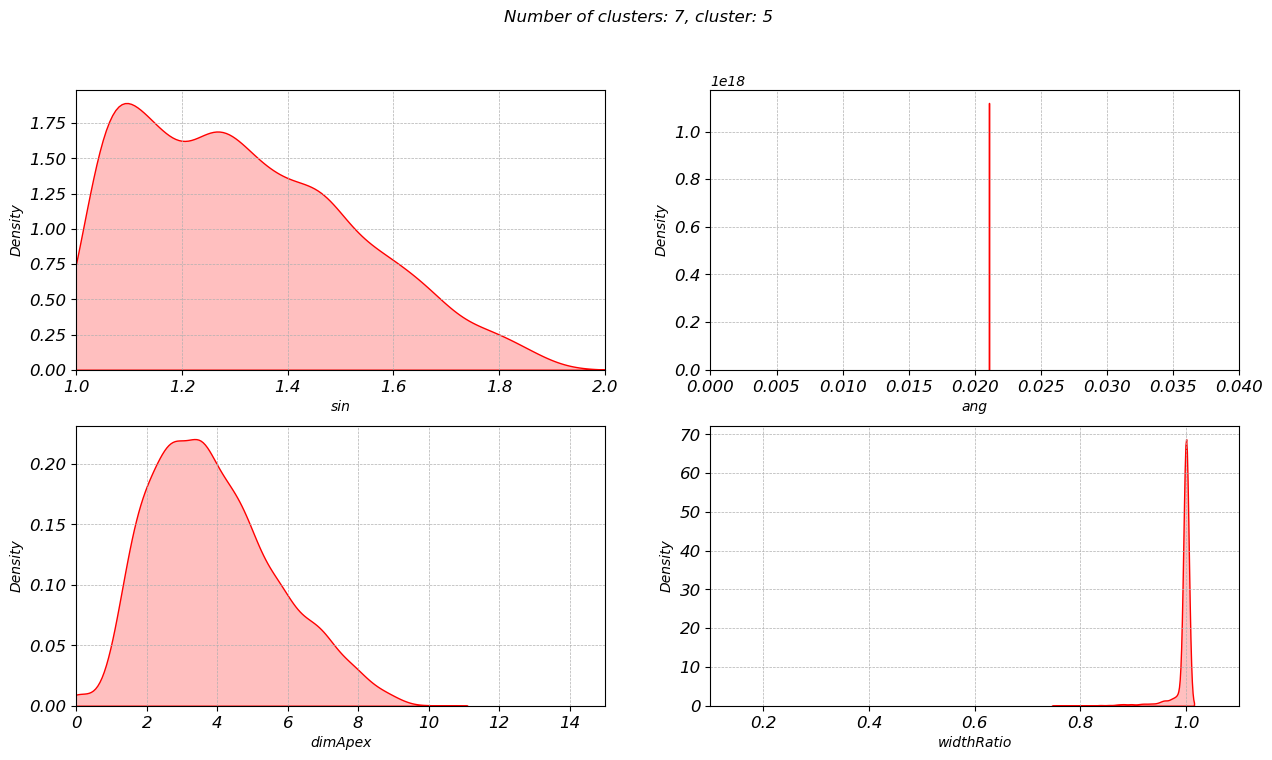

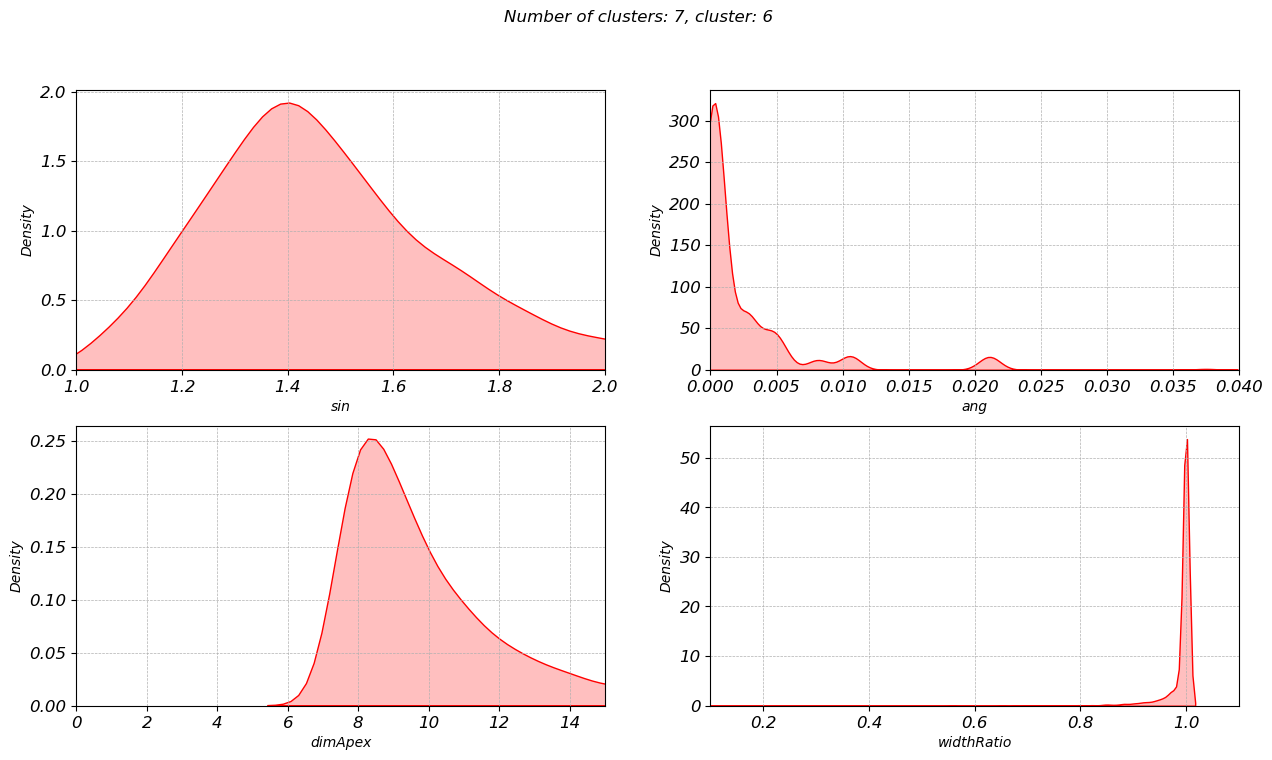

In [79]:
plot_kde_cluster(dfReachCluster, ['sin','ang', 'dimApex' , 'widthRatio'], 'KMeans_pca_7', 7)

## KDE var vs var

Linear relationship between axis (sin, ang): 2
inf

Linear relationship between axis (sin, ang): 5
1.9896165905957605e+34

Linear relationship between axis (ang, dimApex): 2
inf

Linear relationship between axis (ang, dimApex): 5
1.2112988600469133e+35

Linear relationship between axis (ang, widthRatio): 2
inf

Linear relationship between axis (ang, widthRatio): 5
2.8157468426960303e+32



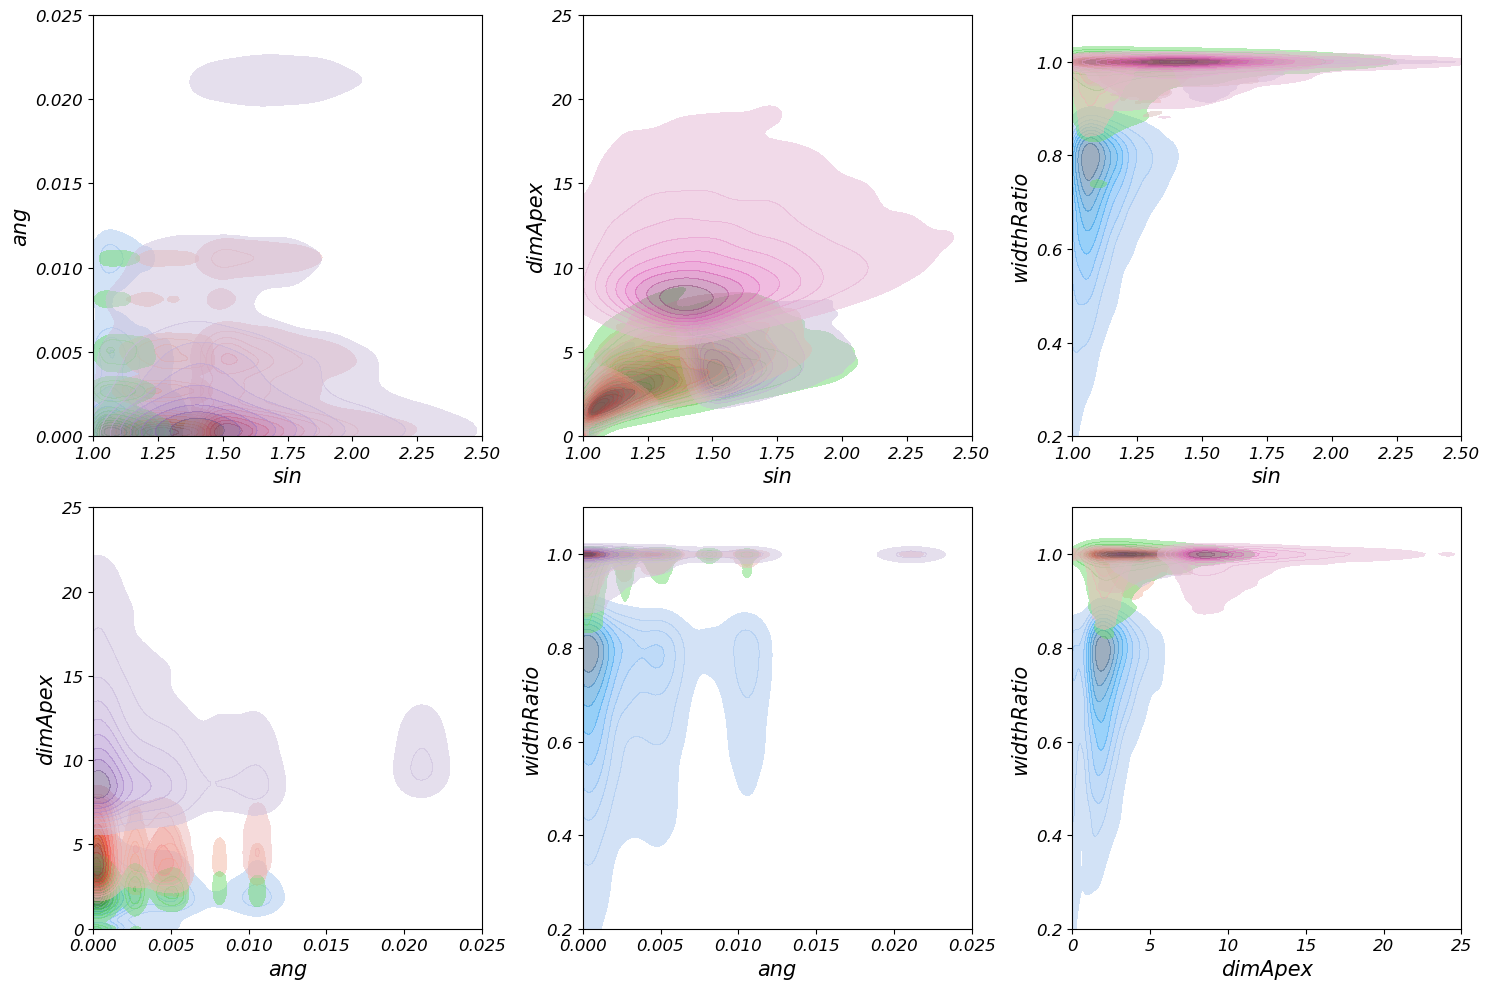

In [98]:
def plotKDE(df,clusterCol,cols, axisRange):
    plotComb = list(itertools.combinations(cols,2))

    unique_labels = sorted(df[clusterCol].dropna().unique())
    labels = []

    if len(plotComb) % 2:
        nrows, ncols = int(len(plotComb)/2), 2
    else:
        nrows, ncols = int(len(plotComb)/3), 3

    f, ax = plt.subplots(nrows=nrows, ncols = ncols, figsize = [15, 5*nrows])
    ax    = ax.flatten()

    for i, pc in enumerate(plotComb):
        XR = axisRange[pc[0]]
        for l, label in enumerate(unique_labels):
            label = int(label)
            subset = df[df[clusterCol] == label]
            
            kdeT = subset[[pc[0], pc[1]]].dropna().to_numpy()
            cov = np.cov(kdeT.T)

            if np.linalg.cond(cov) > 1e10:
                print(f'Linear relationship between axis ({pc[0]}, {pc[1]}): {label}')
                print(np.linalg.cond(cov))
                print()
            else:
                sns.kdeplot(
                    data=subset,
                    x=pc[0],
                    y=pc[1],
                    ax=ax[i],
                    # color=palette[i],
                    fill=True,
                    warn_singular=False,
                    alpha = 0.5
                )
                labels.append(label)


        # Plot limits and layout
        ax[i].set_xlim(axisRange[pc[0]])
        ax[i].set_ylim(axisRange[pc[1]])
        ax[i].set_xlabel(pc[0], fontsize = labelSize)
        ax[i].set_ylabel(pc[1], fontsize = labelSize)
        ax[i].tick_params(axis = 'both', which = 'major', labelsize = tickSize)
    plt.tight_layout()
    plt.show()

axisRange = {'sin': [1,2.5],
             'ang':[0,0.025],
             'dimApex': [0,25],
             'widthRatio':[0.2,1.1]}

plotKDE(dfReachCluster, 'KMeans_pca_7',['sin', 'ang', 'dimApex', 'widthRatio'], axisRange)

# GMM

In [221]:
def fit_GMM(df,c,cols, pca = True, max_iter = 100, n_init = 5, covariance_type = 'tied'):

    gmm = GaussianMixture(n_components=c, covariance_type=covariance_type, random_state=42, n_init = n_init, max_iter = max_iter, init_params='kmeans')#k-means++
    gmm.fit(df[cols])
    print('done Fitting')
    labelsHard = gmm.predict(df[cols])
    labelsSoft = gmm.predict_proba(df[cols])
    if pca == True:
        col = f'GMM_pca_{c}'
    else:
        col = f'GMM_{c}'
    df[f'{col}_hard'] = labelsHard

    for i in range(c):
        df[f'{col}_{i}_soft']=  labelsSoft[:,i]
    return df

def add_cluster_certainty(df,cluster, cert = [0.9,0.95,0.99]):
    cols_of_interest = [col for col in df.columns if f'_{cluster}_' in col  and col.endswith("_soft")]
    for t in cert:

        df.loc[df[cols_of_interest].max(axis=1) >= t, f'GMM_pca_{cluster}_{int(t*100)}'] = df[f'GMM_pca_{cluster}_hard']
    return df

In [222]:
clusters = 7

In [223]:
dfReachCluster = fit_GMM(dfReachCluster, clusters, pcaReachCols)
dfBendCluster  = fit_GMM(dfBendCluster , clusters, pcaBendCols)

done Fitting
done Fitting


In [224]:
dfReachCluster = add_cluster_certainty(dfReachCluster, clusters)
dfBendCluster  = add_cluster_certainty(dfBendCluster , clusters)

### Distribution

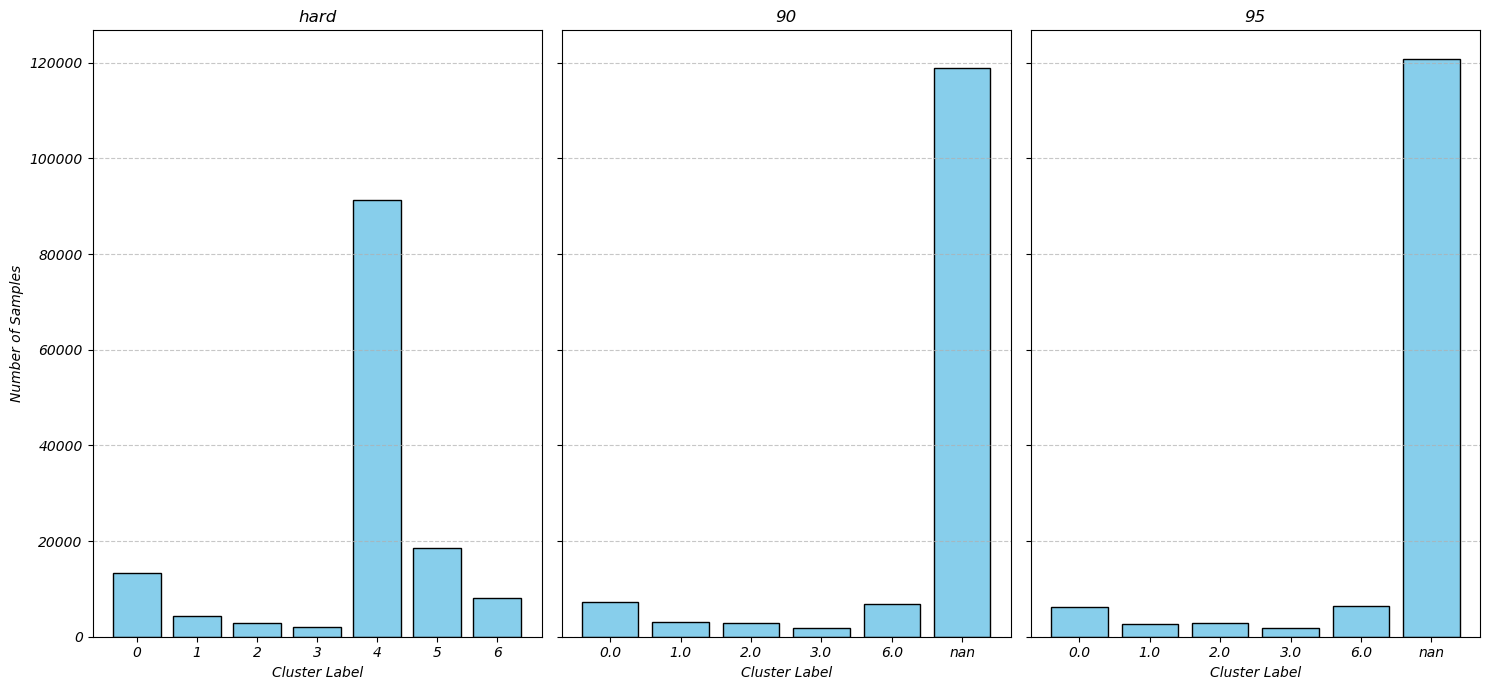

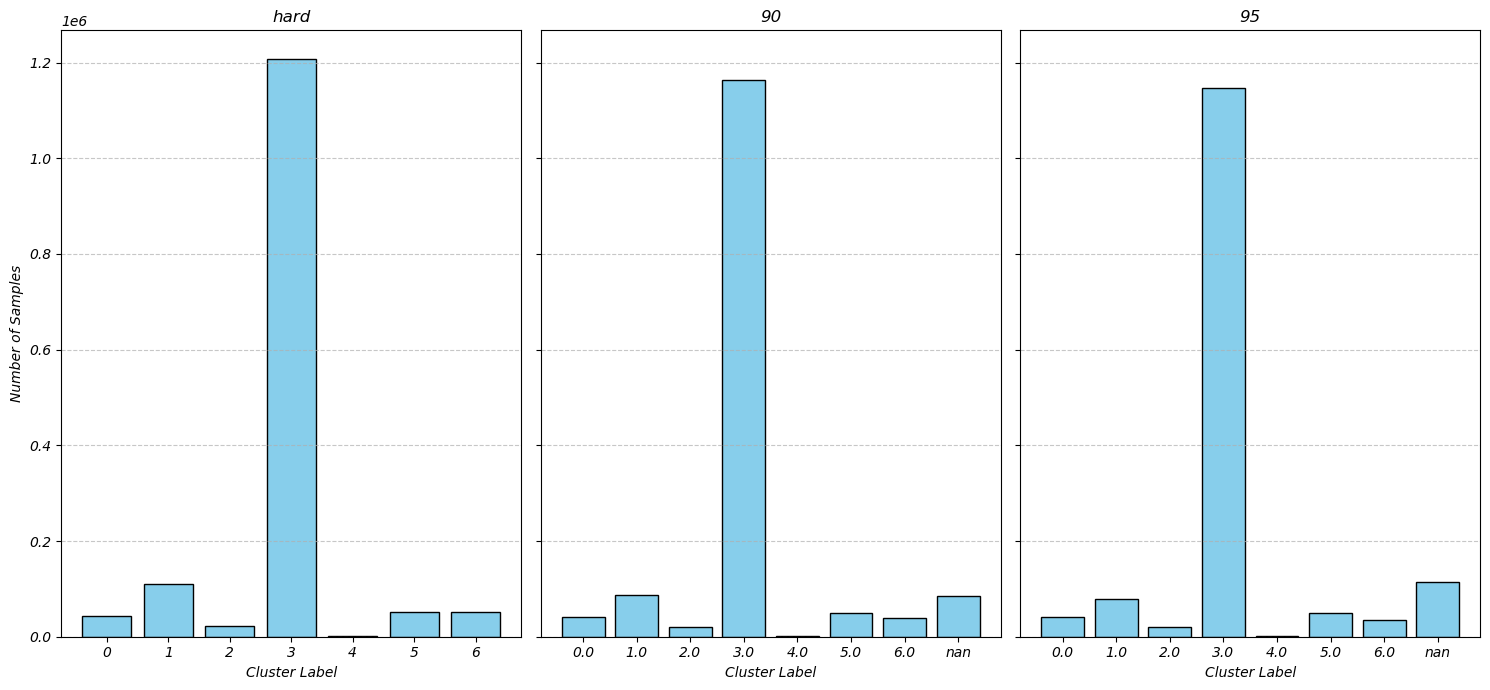

In [225]:
bar_cluster_distribution_plot(dfReachCluster,'GMM_pca_7', ['hard', '90', '95'])
bar_cluster_distribution_plot(dfBendCluster,'GMM_pca_7', ['hard', '90', '95'])

## KDE per cluster

In [31]:
cols = ['sin', 'ang', 'apex', 'widthRatio']
plotComb = list(itertools.combinations(cols, 2))

In [34]:
dfReachCluster[dfReachCluster['GMM_pca_7_hard'] == 2]['ang']

23187    0.037507
23188    0.037507
23189    0.037507
23190    0.037507
23191    0.037507
           ...   
69704    0.037507
70075    0.037507
70077    0.037507
70078    0.037507
70079    0.037507
Name: ang, Length: 4530, dtype: float64

/tmp/ipykernel_22598/1342897764.py:16: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  L = sns.kdeplot(data = data, x = cols[count], ax=axs[i,j], fill=True, color = 'red', legend = False)


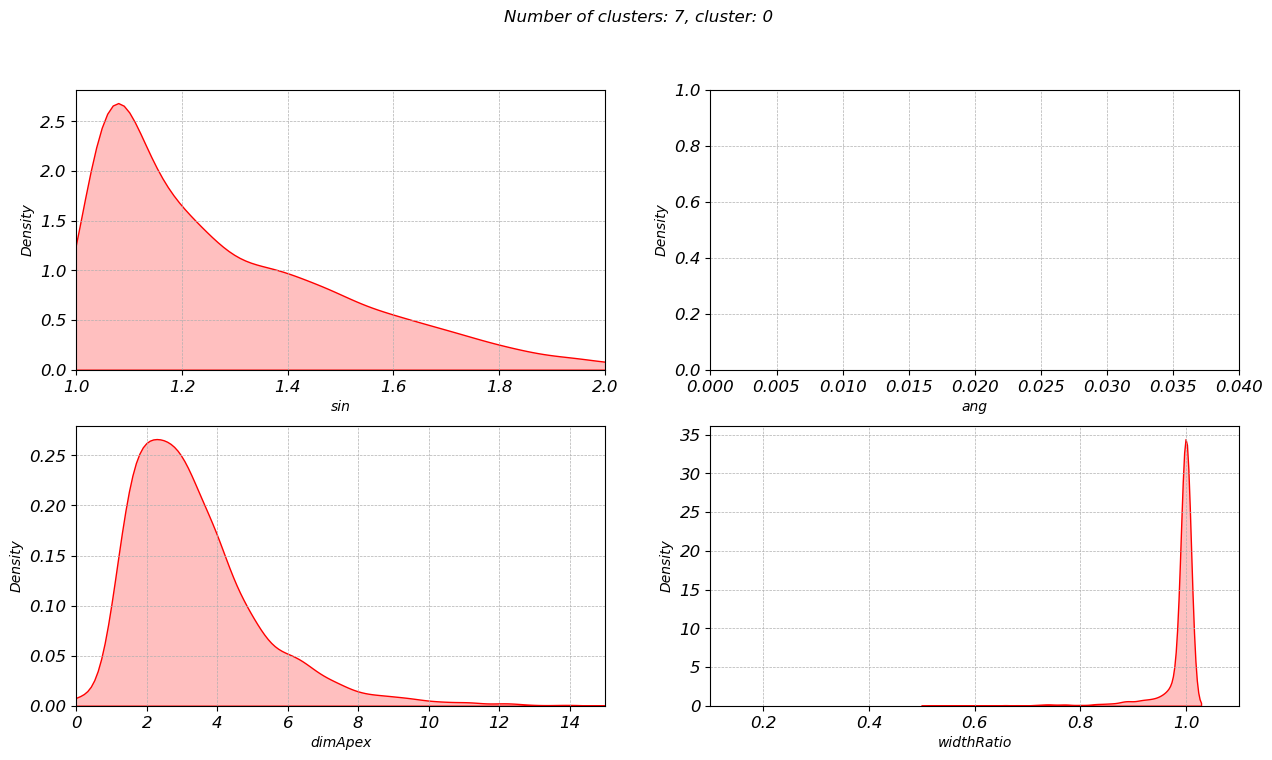

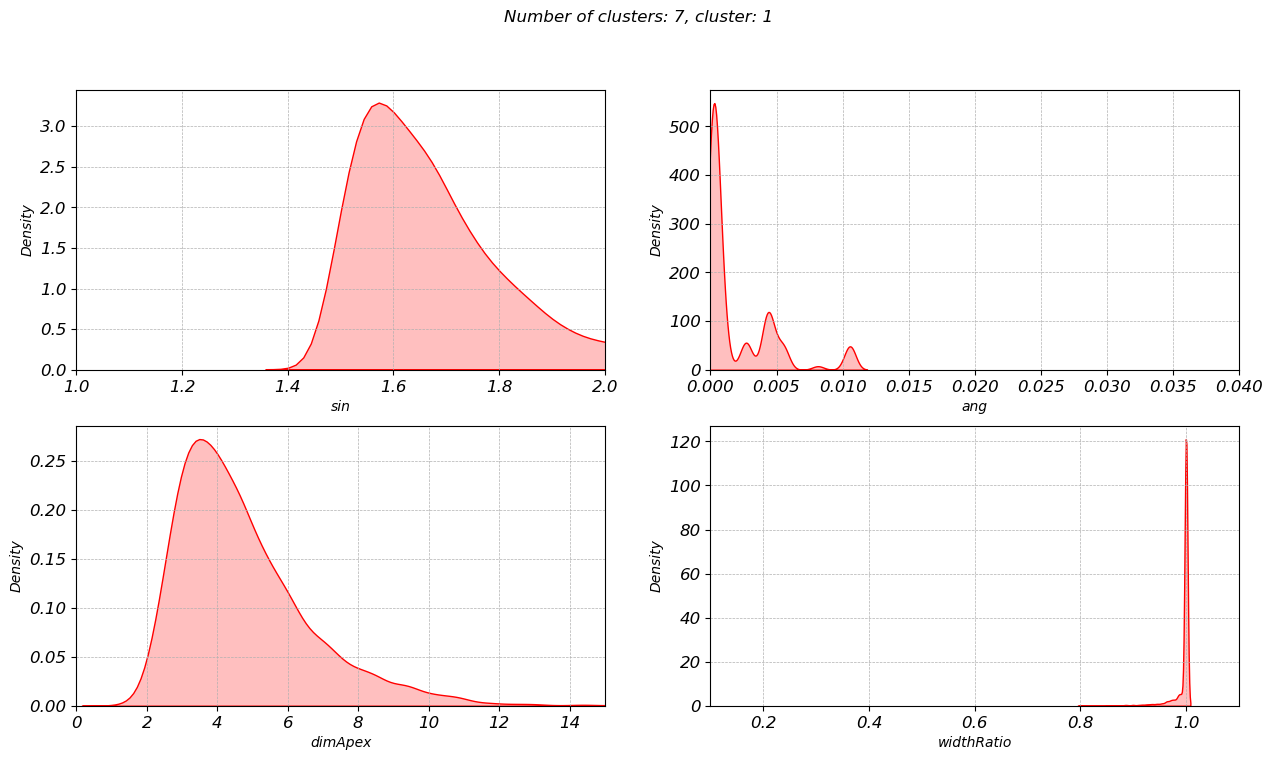

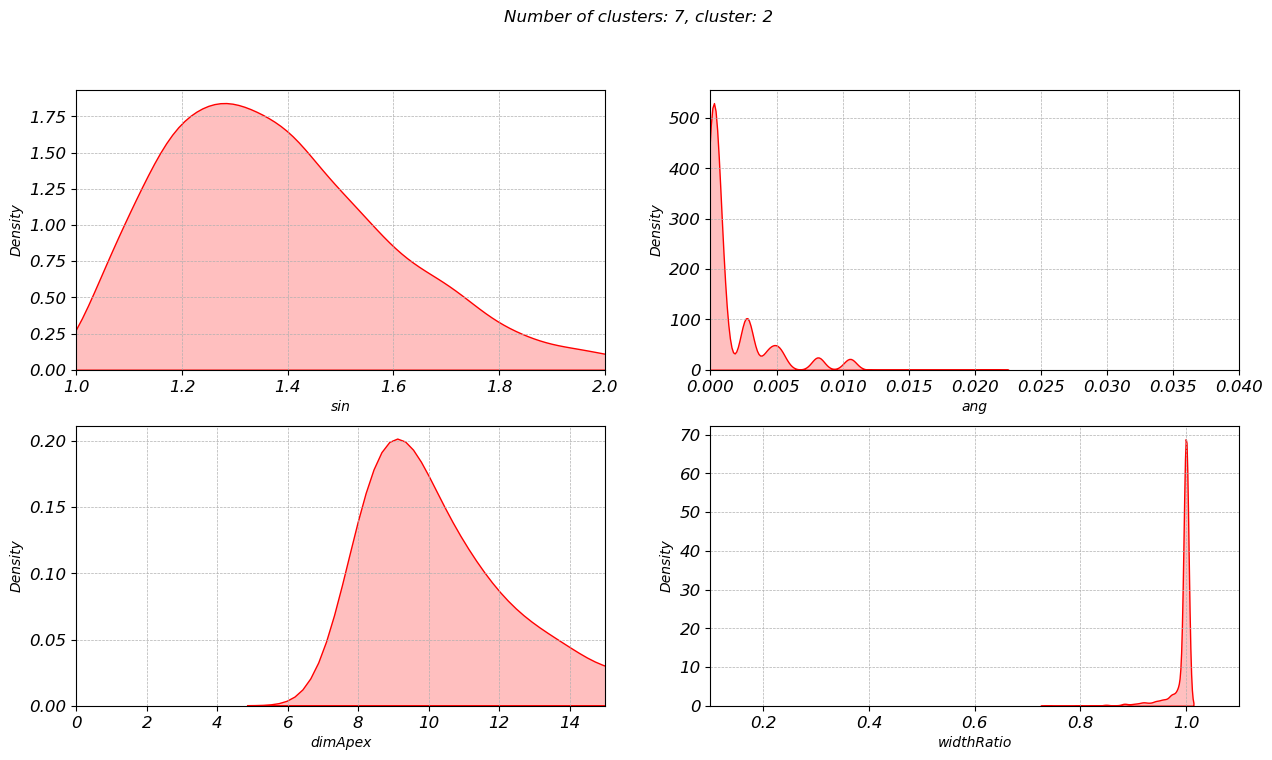

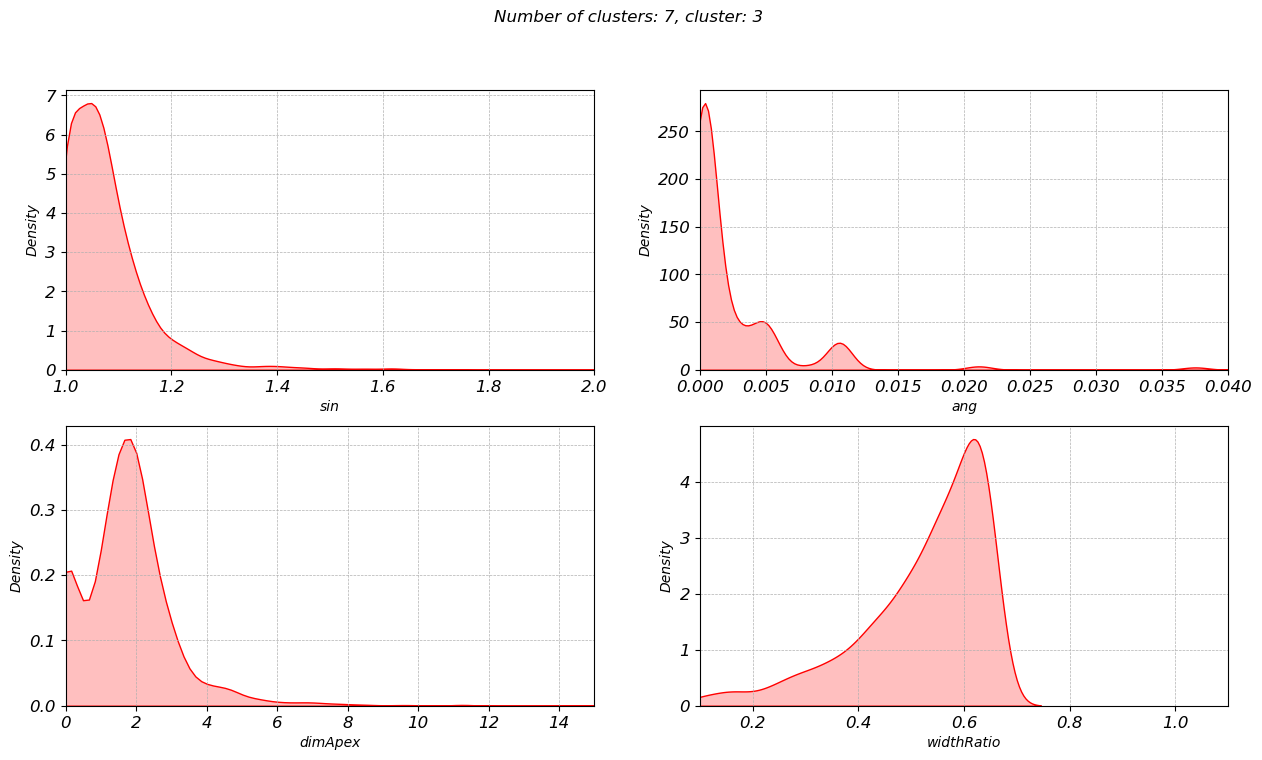

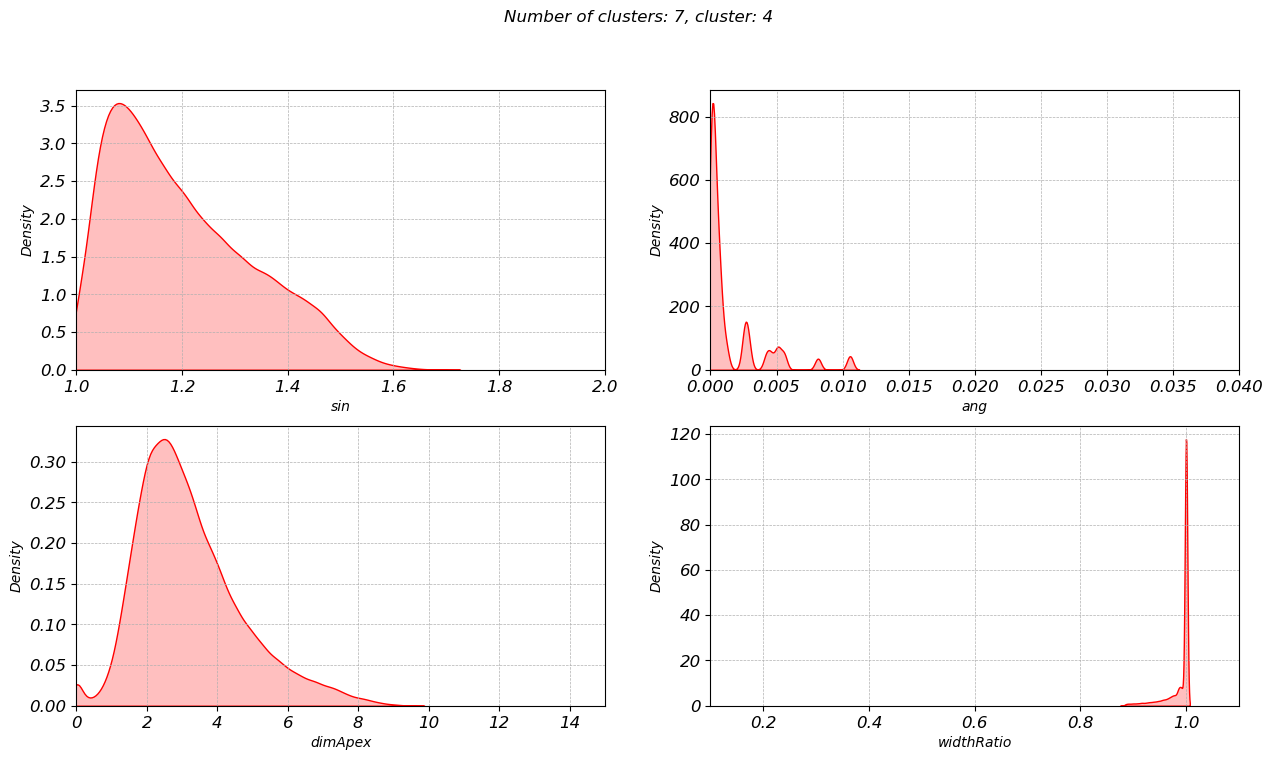

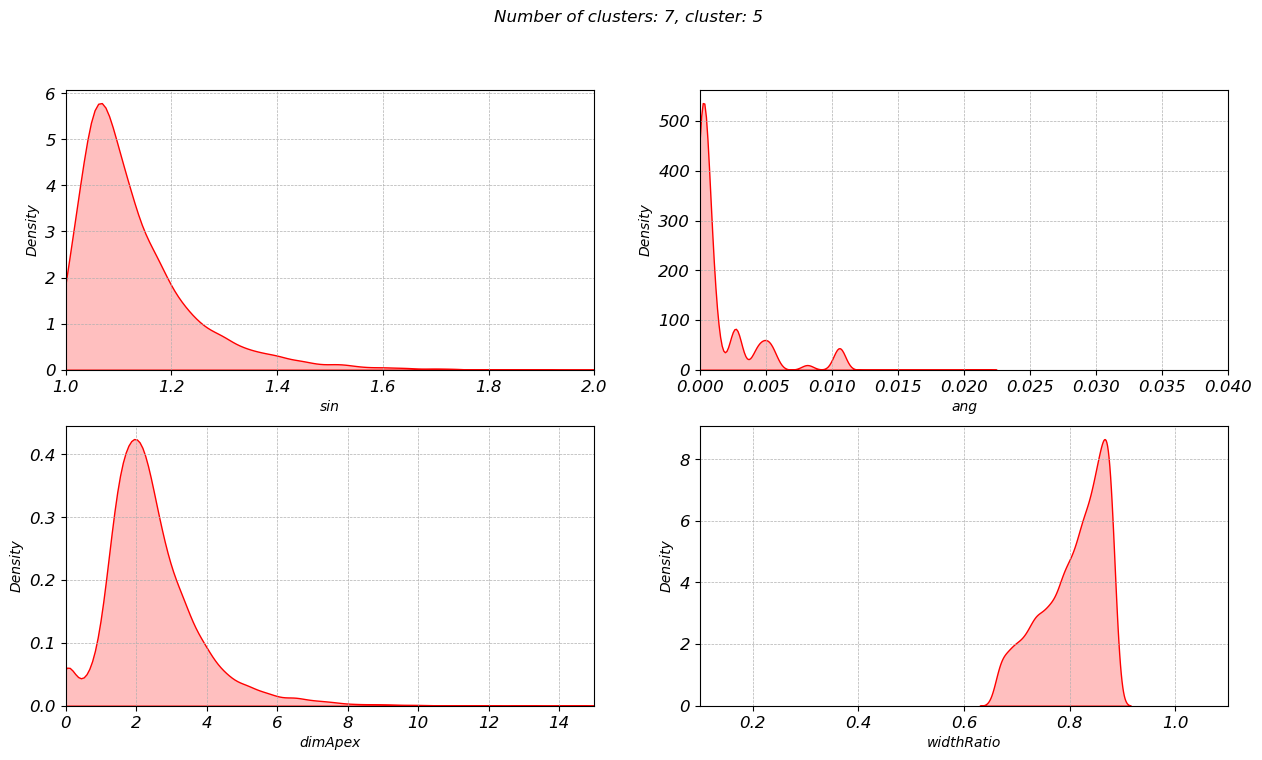

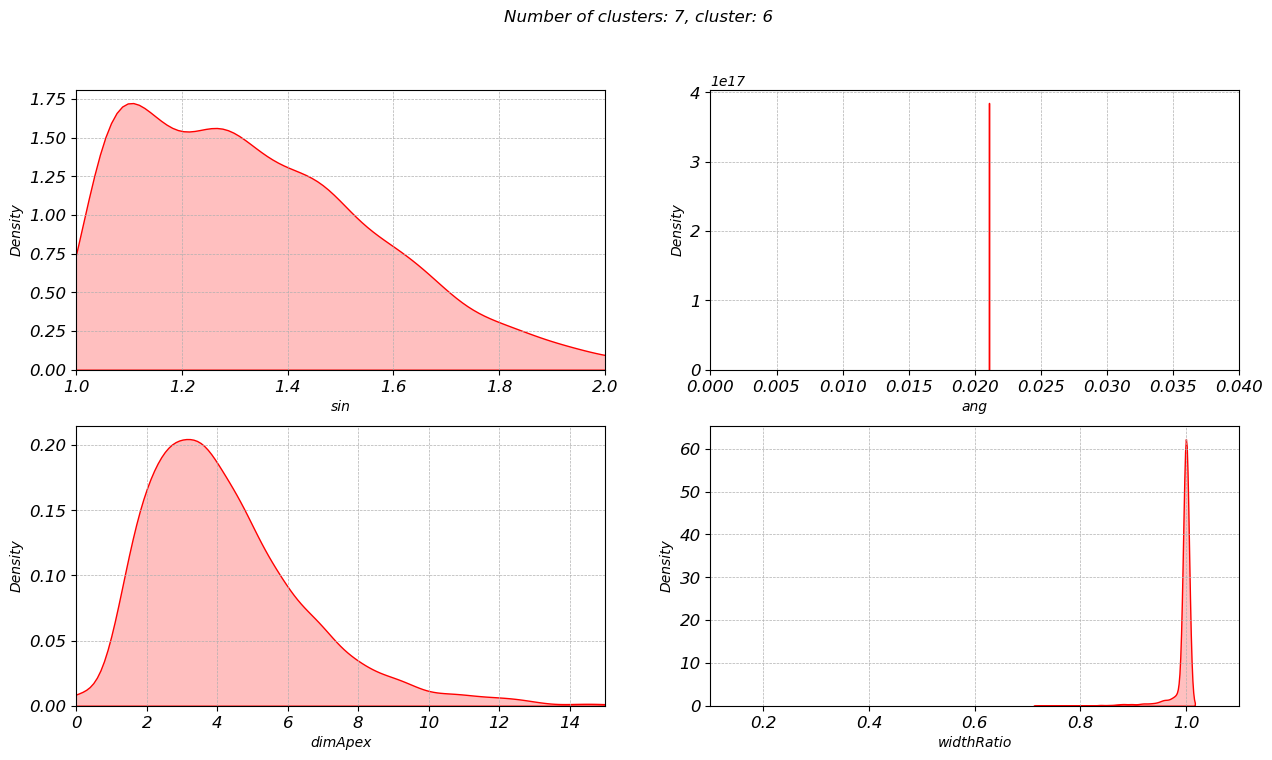

In [74]:

plot_kde_cluster(dfReachCluster, ['sin', 'ang', 'dimApex', 'widthRatio'],'GMM_pca_7_hard', 7 )

# Merge with GPKG

In [ ]:
saveReachCols = ['combined_reach_id', 'reach_id', 'file_cont', 'file_id',
                'sin', 'dimApex', 'ang', 'widthRatio'
                'KMeans_pca_7'
                'GMM_pca_7_hard'
                ]
saveBendCols  = ['combined_reach_id', 'reach_id', 'file_cont', 'file_id',
                'sin', 'dimApex', 'ang', 'widthRatio'
                'KMeans_pca_7'
                'GMM_pca_7_hard'
                ]
dfReachSave = dfReachCluster[saveReachCols]
dfBendSave  = dfBendCluster[saveBendCols]]

In [232]:
a = [[1,2,3],[4,5,6],[7,8,9,10]]
list(itertools.product(*a))

[(1, 4, 7),
 (1, 4, 8),
 (1, 4, 9),
 (1, 4, 10),
 (1, 5, 7),
 (1, 5, 8),
 (1, 5, 9),
 (1, 5, 10),
 (1, 6, 7),
 (1, 6, 8),
 (1, 6, 9),
 (1, 6, 10),
 (2, 4, 7),
 (2, 4, 8),
 (2, 4, 9),
 (2, 4, 10),
 (2, 5, 7),
 (2, 5, 8),
 (2, 5, 9),
 (2, 5, 10),
 (2, 6, 7),
 (2, 6, 8),
 (2, 6, 9),
 (2, 6, 10),
 (3, 4, 7),
 (3, 4, 8),
 (3, 4, 9),
 (3, 4, 10),
 (3, 5, 7),
 (3, 5, 8),
 (3, 5, 9),
 (3, 5, 10),
 (3, 6, 7),
 (3, 6, 8),
 (3, 6, 9),
 (3, 6, 10)]

In [234]:
*a

SyntaxError: can't use starred expression here (2205420745.py, line 1)

In [236]:
[max_iter, covType, init, init_type, clusters]

[[100], [12, 3, 5], 5, [1], [1, 2, 3]]

In [237]:
# scores = []
# for max_iter in [100]:
#     for covType in ['diag', 'tied']:
#         for init in [5]:
#             for n in clusters:

max_iter = [100]
covType = ['diag', 'tied']
init = [5]
init_type = ['kmeans']
clusters = [1,2,3]
list(itertools.product(*[max_iter, covType, init, init_type, clusters]))

[(100, 'diag', 5, 'kmeans', 1),
 (100, 'diag', 5, 'kmeans', 2),
 (100, 'diag', 5, 'kmeans', 3),
 (100, 'tied', 5, 'kmeans', 1),
 (100, 'tied', 5, 'kmeans', 2),
 (100, 'tied', 5, 'kmeans', 3)]

In [ ]:
def saveReachCluster_gpkg():
    files = np.sort(glob(directory + f'results/new_segments/{cont}_??_50_02_conf.gpkg'))

    # for cont in ['na']:
            print(cont)
            keepCols = ['combined_reach_id',  'bendDistOut', 'geometry']
            files = np.sort(glob(directory + f'results/new_segments/{cont}_??_50_02_conf.gpkg'))
def saveBendCluster_gpkg():
    for cont in ['af', 'eu', 'oc', 'as', 'sa', 'na']:
    # for cont in ['na']:
        print(cont)
        keepCols = ['combined_reach_id',  'bendDistOut', 'geometry']
        files = np.sort(glob(directory + f'results/single_values/{cont}_??_50_02_conf.gpkg'))
        # files = files[[12, 13, 14, 15]]
        for f in tqdm(files):
            gdf = gpd.read_file(f)
            gdf = gdf[keepCols]

            # add bendRank
            gdf['bendRank'] = gdf.groupby('combined_reach_id')['bendDistOut'].rank(ascending=False).astype(int)
            gdf['bendID']   = gdf['combined_reach_id'].astype(int).astype(str) + '_' + gdf['bendRank'].astype(str)

            # Merge with labelled df
            dfClusterC = dfSave[dfSave['file'] == cont]
            dfNew      = gdf.merge(dfClusterC, on = 'bendID', how = 'left')
            dfNew.to_file(directory + f'results/cluster/{cont}_{f[-18:-16]}_bend_cluster.gpkg', driver = 'GPKG')